# STEP 1: CLEANING THE DATAFRAME #

In [145]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as ticker
import seaborn as sns
import datetime
from typing import Literal, overload, Tuple, Optional
from scipy.stats import skew
from sklearn.model_selection import train_test_split, GridSearchCV, KFold, cross_val_score
from statsmodels.stats.outliers_influence import variance_inflation_factor
from statsmodels.tools.tools import add_constant
from sklearn.linear_model import LinearRegression, Ridge, Lasso
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
from sklearn.preprocessing import StandardScaler, PolynomialFeatures, OneHotEncoder
from sklearn.ensemble import RandomForestRegressor, StackingRegressor
from sklearn.pipeline import Pipeline
from sklearn.pipeline import make_pipeline
from sklearn.compose import ColumnTransformer, TransformedTargetRegressor
from sklearn.feature_selection import RFECV
from sklearn.base import clone

from xgboost import XGBRegressor


### 1.1 DATA LOADING AND INSPECTING THE DATASET ###

In [82]:
df = pd.read_csv('../data/cleaned_properties_dataset_2026-03-12-15h10.csv', sep = ',')

In [83]:
print(df.shape)
print(df.info())

(13097, 23)
<class 'pandas.DataFrame'>
RangeIndex: 13097 entries, 0 to 13096
Data columns (total 23 columns):
 #   Column                  Non-Null Count  Dtype  
---  ------                  --------------  -----  
 0   url                     13097 non-null  str    
 1   zip_code                13097 non-null  int64  
 2   city                    13097 non-null  str    
 3   province                13097 non-null  str    
 4   region                  13097 non-null  str    
 5   type_of_property        13097 non-null  str    
 6   subtype_of_property     13097 non-null  str    
 7   price_sqm               12286 non-null  float64
 8   price                   13097 non-null  int64  
 9   type_of_sale            13097 non-null  str    
 10  number_of_rooms         12848 non-null  float64
 11  living_area             12286 non-null  float64
 12  fully_equipped_kitchen  13097 non-null  int64  
 13  furnished               13097 non-null  bool   
 14  open_fire               13097 non-nul

In [84]:
# checking empty data
df.isna().sum().sort_values(ascending=False)

surface_of_the_land       6888
garden_area               5120
terrace_area              4672
number_of_facades         2949
price_sqm                  811
living_area                811
number_of_rooms            249
subtype_of_property          0
type_of_property             0
region                       0
province                     0
city                         0
zip_code                     0
url                          0
price                        0
open_fire                    0
furnished                    0
fully_equipped_kitchen       0
type_of_sale                 0
garden                       0
terrace                      0
swimming_pool                0
state_of_the_building        0
dtype: int64

In [85]:
# and as %%
(df.isna().mean()*100).sort_values(ascending=False)

surface_of_the_land       52.592197
garden_area               39.092922
terrace_area              35.672291
number_of_facades         22.516607
price_sqm                  6.192258
living_area                6.192258
number_of_rooms            1.901199
subtype_of_property        0.000000
type_of_property           0.000000
region                     0.000000
province                   0.000000
city                       0.000000
zip_code                   0.000000
url                        0.000000
price                      0.000000
open_fire                  0.000000
furnished                  0.000000
fully_equipped_kitchen     0.000000
type_of_sale               0.000000
garden                     0.000000
terrace                    0.000000
swimming_pool              0.000000
state_of_the_building      0.000000
dtype: float64

In [86]:
# checking is anything left missing
print(f"Number of properties with 'leaving_area' = 0: {(df['living_area'] == 0).sum()}")

print(f"Number of properties with 'number_of_rooms' = 0: {(df['number_of_rooms'] == 0).sum()}")

Number of properties with 'leaving_area' = 0: 0
Number of properties with 'number_of_rooms' = 0: 109


In [87]:
# HAS TO DO IT, WILL FIX IN CLEANER.PY TOMORROW
df.loc[((df["number_of_rooms"] == 0)|(df["number_of_rooms"]>100)), "number_of_rooms"] = np.nan
print(f"Number of properties with 'number_of_rooms' = 0: {(df['number_of_rooms'] == 0).sum()}")

Number of properties with 'number_of_rooms' = 0: 0


In [88]:
df[['city','province','region']].nunique()

city        1417
province      11
region         3
dtype: int64

In [89]:
df[['price','living_area','number_of_rooms']].describe()

,price,living_area,number_of_rooms
count,1.309700e+04,12286.000000,12738.000000
mean,4.388094e+05,165.652938,2.983514
std,5.276267e+05,144.463064,1.876340
min,6.200000e+02,12.000000,1.000000
25%,2.350000e+05,91.000000,2.000000
50%,3.350000e+05,134.000000,3.000000
75%,4.950000e+05,197.000000,4.000000
max,2.600000e+07,3500.000000,100.000000


### 1.2. COLUMN DROP ###

In [90]:
df = df.drop(columns=["url", 'price_sqm'])
df.columns

Index(['zip_code', 'city', 'province', 'region', 'type_of_property',
       'subtype_of_property', 'price', 'type_of_sale', 'number_of_rooms',
       'living_area', 'fully_equipped_kitchen', 'furnished', 'open_fire',
       'terrace', 'terrace_area', 'garden', 'garden_area',
       'surface_of_the_land', 'number_of_facades', 'swimming_pool',
       'state_of_the_building'],
      dtype='str')

### 1.3. CHECKING FOR DUPLICATES ###

In [91]:
def drop_duplicate_rows(df: pd.DataFrame) -> pd.DataFrame:
    """
    Identifies and removes duplicate rows from the DataFrame.

    This step ensures the dataset meets the 'minimum 10,000 unique inputs'
    requirement for the ImmoEliza project.

    Args:
        df (pd.DataFrame): The DataFrame containing raw property data.

    Returns:
        pd.DataFrame: A cleaned DataFrame with unique rows and a reset index.
    """
    # Count the number of duplicate entries before removal
    duplicate_count = df.duplicated().sum()

    if duplicate_count > 0:
        print(f"Found {duplicate_count} duplicate rows. Removing them...")
        # Remove duplicates and reset the index to keep it continuous
        df_cleaned = df.drop_duplicates().reset_index(drop=True)
        print("Duplicates removed successfully.")
        return df_cleaned

    print("No duplicates found in the dataset.")
    return df


In [92]:
drop_duplicate_rows(df)

Found 224 duplicate rows. Removing them...
Duplicates removed successfully.


,zip_code,city,province,region,type_of_property,subtype_of_property,price,type_of_sale,number_of_rooms,living_area,...,furnished,open_fire,terrace,terrace_area,garden,garden_area,surface_of_the_land,number_of_facades,swimming_pool,state_of_the_building
0,2250,Olen,Antwerp,Flanders,House,residence,549000,for sale,4.0,317.0,...,False,False,True,NaN,True,NaN,391.0,2.0,False,2
1,4030,Grivegnée,Liege,Wallonia,House,residence,215000,for sale,3.0,100.0,...,False,False,True,24.0,False,0.0,92.0,2.0,False,3
2,1000,Brussels,Brussels,Brussels,Apartment,penthouse,479000,for sale,3.0,126.0,...,False,False,True,27.0,False,0.0,NaN,2.0,False,2
3,1040,Etterbeek,Brussels,Brussels,Apartment,apartment,530000,for sale,2.0,93.0,...,False,False,True,10.0,False,0.0,NaN,2.0,False,4
4,5541,Hastière-par-delà,Namur,Wallonia,House,chalet,139000,for sale,2.0,51.0,...,False,False,True,NaN,True,NaN,234.0,4.0,False,4
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
12868,3271,Averbode,Flemish Brabant,Flanders,House,residence,369000,for sale,3.0,215.0,...,False,False,True,NaN,True,NaN,730.0,2.0,False,2
12869,4219,Meeffe,Liege,Wallonia,House,residence,285000,for sale,4.0,NaN,...,False,False,True,NaN,True,222.0,487.0,4.0,False,2
12870,2018,Antwerp,Antwerp,Flanders,Apartment,duplex,189000,for sale,1.0,49.0,...,False,False,True,2.0,False,0.0,NaN,NaN,False,2
12871,1080,Sint-Jans-Molenbeek,Brussels,Brussels,Apartment,apartment,249000,for sale,1.0,76.0,...,False,False,False,0.0,False,0.0,NaN,NaN,False,2


### 1.4. FIXING DATA TYPES ###

In [93]:
df['zip_code'] = df['zip_code'].astype('str')

In [94]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 13097 entries, 0 to 13096
Data columns (total 21 columns):
 #   Column                  Non-Null Count  Dtype  
---  ------                  --------------  -----  
 0   zip_code                13097 non-null  str    
 1   city                    13097 non-null  str    
 2   province                13097 non-null  str    
 3   region                  13097 non-null  str    
 4   type_of_property        13097 non-null  str    
 5   subtype_of_property     13097 non-null  str    
 6   price                   13097 non-null  int64  
 7   type_of_sale            13097 non-null  str    
 8   number_of_rooms         12738 non-null  float64
 9   living_area             12286 non-null  float64
 10  fully_equipped_kitchen  13097 non-null  int64  
 11  furnished               13097 non-null  bool   
 12  open_fire               13097 non-null  bool   
 13  terrace                 13097 non-null  bool   
 14  terrace_area            8425 non-null   float64
 

In [95]:
def optimize_dataframe_types(df) -> pd.DataFrame:
    """
    Standardizes and optimizes data types across the property dataframe.

    Converts features to nullable integers (Int64) for counts and
    standard booleans for flags, ensuring memory efficiency and
    imputation readiness.
    """
    # Automatically infer the best possible types (e.g., objects to strings)
    df = df.convert_dtypes()

    # Integer columns (using nullable Int64 to preserve NaNs)
    int_cols = [
        'number_of_rooms', 'fully_equipped_kitchen',
        'number_of_facades', 'state_of_the_building',
        'price_sqm', 'living_area', 'terrace_area',
        'garden_area', 'surface_of_the_land', 'price'
        ]
    for col in int_cols:
        df = cast_column_type(df, col, 'Int64')

    # Boolean columns
    bool_cols = [
        'furnished', 'open_fire', 'terrace',
        'garden', 'swimming_pool'
    ]
    for col in bool_cols:
        df = cast_column_type(df, col, bool)

    return df


def cast_column_type(df, column_name, data_type) -> pd.DataFrame:
    """
    Safely casts a specific column to the target data type.

    Args:
        df (pd.DataFrame): The dataframe to modify.
        column_name (str): The column to cast.
        data_type: The target type (e.g., 'Int64', bool, str).
    """
    if column_name not in df.columns:
        return df

    if data_type == bool:
        # Fill missing flags with False/0 before converting to boolean
        df[column_name] = df[column_name].fillna(0).astype(bool)
    else:
        df[column_name] = df[column_name].astype(data_type)

    return df


In [96]:
df = optimize_dataframe_types(df)

In [97]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 13097 entries, 0 to 13096
Data columns (total 21 columns):
 #   Column                  Non-Null Count  Dtype 
---  ------                  --------------  ----- 
 0   zip_code                13097 non-null  string
 1   city                    13097 non-null  string
 2   province                13097 non-null  string
 3   region                  13097 non-null  string
 4   type_of_property        13097 non-null  string
 5   subtype_of_property     13097 non-null  string
 6   price                   13097 non-null  Int64 
 7   type_of_sale            13097 non-null  string
 8   number_of_rooms         12738 non-null  Int64 
 9   living_area             12286 non-null  Int64 
 10  fully_equipped_kitchen  13097 non-null  Int64 
 11  furnished               13097 non-null  bool  
 12  open_fire               13097 non-null  bool  
 13  terrace                 13097 non-null  bool  
 14  terrace_area            8425 non-null   Int64 
 15  garden       

### 1.5. LOGIC RULES FOR BINARY FEATURES ###

In [ ]:
# Number_of_rooms
# upper_limit = df['number_of_rooms'].quantile(0.9999)
# print(upper_limit)
#df['number_of_rooms'] = np.where(df['number_of_rooms'] > upper_limit, upper_limit, df['number_of_rooms'])


### 1.6. CREATING DOMAIN FEATURES ###

In [ ]:
# df['outdoor_space'] = df['terrace'] | df['garden']
# df['total_area'] = df['living_area'].fillna(0) + df['terrace_area'].fillna(0) + df['garden_area'].fillna(0)

# STEP 2: DATA FORMATTING ###

In [ ]:
# Function to check and print outliers in data column (coeff = 1.5 is market standard, coeff = 3 is very conservative)
def func_check_outliers_iqr(df, column, coeff=1.5):
    Q1 = df[column].quantile(0.25)
    Q3 = df[column].quantile(0.75)
    IQR = Q3 - Q1

    lower_bound = Q1 - coeff * IQR
    upper_bound = Q3 + coeff * IQR

    outliers = df[(df[column] < lower_bound) | (df[column] > upper_bound)]
    print(f'The number of outliers INCLUDING NaN in {column} is {len(outliers)}')
    print(f"Range [{lower_bound:.2f}, {upper_bound:.2f}]")
    print(outliers)

In [ ]:
# Function to check and print outliers in data column based on 1 and 99 quantile
def func_check_outliers_percentile(df, column):
    lower_bound = df[column].quantile(0.01)
    upper_bound = df[column].quantile(0.99)

    outliers = df[(df[column] < lower_bound) | (df[column] > upper_bound)]
    print(f'The number of outliers INCLUDING NaN in {column} is {len(outliers)}')
    print(f"Range [{lower_bound:.2f}, {upper_bound:.2f}]")
    print(outliers)

In [ ]:
# Function to check and FILTER OUT outliers in data column
# (coeff = 1.5 is market standard, coeff = 3 is very conservative)
def func_remove_outliers_iqr(df, column, coeff = 1.5):
    Q1 = df[column].quantile(0.25)
    Q3 = df[column].quantile(0.75)
    IQR = Q3 - Q1

    lower_bound = Q1 - coeff * IQR
    upper_bound = Q3 + coeff * IQR

    is_in_bounds = (df[column] >= lower_bound) & (df[column] <= upper_bound)
     # keep my empty cells in-tact
    is_nan = df[column].isna()

    df_filtered = df[is_in_bounds | is_nan].copy()
    df_outliers = df[~(is_in_bounds | is_nan)].copy()

    print(f"From column '{column}' the following number of outliers {len(df_outliers)} were deleted")
    print(f'Saved rows with empty cells: {is_nan.sum()}')
    print(f"Range [{lower_bound:.2f}, {upper_bound:.2f}]")

    return df_filtered, df_outliers


In [ ]:
# Function to check and FILTER OUT outliers in data column
# based on 1 and 99 percentiles
def func_remove_outliers_percentile(df, column):
    lower_bound = df[column].quantile(0.01)
    upper_bound = df[column].quantile(0.99)

    is_in_bounds = (df[column] >= lower_bound) & (df[column] <= upper_bound)
    # keep my empty cells in-tact
    is_nan = df[column].isna()

    df_filtered = df[is_in_bounds | is_nan].copy()
    df_outliers = df[~(is_in_bounds | is_nan)].copy()

    print(f"From column '{column}' the following number of outliers {len(df_outliers)} were deleted")
    print(f'Saved rows with empty cells: {is_nan.sum()}')
    print(f"Range [{lower_bound:.2f}, {upper_bound:.2f}]")

    return df_filtered, df_outliers

In [98]:
# Function to check outliers
# --- Overload definitions for IDE IntelliSense ---

@overload
def func_check_outliers(
    df: pd.DataFrame, 
    column: str, 
    *, 
    mode: Literal["IQR"], 
    coeff: float = 1.5
) -> pd.DataFrame: ...

@overload
def func_check_outliers(
    df: pd.DataFrame, 
    column: str, 
    *, 
    mode: Literal["Quantile"], 
    quantile_low: float = 0.01, 
    quantile_high: float = 0.99
) -> pd.DataFrame: ...

# --- Main Implementation ---

def func_check_outliers(
    df: pd.DataFrame, 
    column: str, 
    *, 
    mode: Literal["IQR", "Quantile"], 
    coeff: Optional[float] = None, 
    quantile_low: Optional[float] = None, 
    quantile_high: Optional[float] = None
) -> pd.DataFrame:
    """
    Identifies and returns outliers in a specific DataFrame column using chosen method.

    The function provides two statistical approaches to define outlier boundaries:
    1. IQR (Interquartile Range): Bounds are set as Q1 - coeff*IQR and Q3 + coeff*IQR.
    2. Quantile: Bounds are set by specific lower and upper probabilities.

    Args:
        df (pd.DataFrame): The source DataFrame.
        column (str): Name of the column to analyze for outliers.
        mode (Literal["IQR", "Quantile"]): Outlier detection method to use.
        coeff (float, optional): Multiplier for the IQR. Defaults to 1.5. 
            Commonly 1.5 for outliers, 3.0 for extreme outliers.
        quantile_low (float, optional): Lower probability threshold (0 to 1). Defaults to 0.01.
        quantile_high (float, optional): Upper probability threshold (0 to 1). Defaults to 0.99.

    Returns:
        pd.DataFrame: A filtered DataFrame containing only the rows identified as outliers.

    Raises:
        ValueError: If mode is invalid or quantile range is mathematically incorrect.
    """
    
    col_data = df[column]

    if mode == 'IQR':
        coeff = coeff if coeff is not None else 1.5
        q1 = col_data.quantile(0.25)
        q3 = col_data.quantile(0.75)
        iqr = q3 - q1
        lower_bound = q1 - coeff * iqr
        upper_bound = q3 + coeff * iqr
        method_desc = f"IQR (coeff={coeff})"

    elif mode == 'Quantile':
        if not (0 <= quantile_low < quantile_high <= 1):
            raise ValueError(f"Invalid range: quantile_low ({quantile_low}) must be < quantile_high ({quantile_high}) and both within [0, 1]")
        
        quantile_low = quantile_low if quantile_low is not None else 0.01
        quantile_high = quantile_high if quantile_high is not None else 0.99

        lower_bound = col_data.quantile(quantile_low)
        upper_bound = col_data.quantile(quantile_high)
        method_desc = f"Quantile ({quantile_low} - {quantile_high})"
    
    else:
        # Fallback error for non-typed environments
        raise ValueError("Parameter 'mode' must be either 'IQR' or 'Quantile'")

    # Common filtering logic
    df_outliers = df[(col_data < lower_bound) | (col_data > upper_bound)]
    
    print(f"--- Outlier Analysis [{method_desc}] ---")
    print(f"Target column: '{column}'")
    print(f"Calculated range: [{lower_bound:.2f}, {upper_bound:.2f}]")
    print(f"Number of outliers found: {len(df_outliers)}")
    
    return df_outliers

In [99]:
# Function to delete outliers
@overload
def func_remove_outliers(
    df: pd.DataFrame, column: str, *, mode: Literal["IQR"], coeff: float = 1.5, reset_index: bool = True
) -> Tuple[pd.DataFrame, pd.DataFrame]: ...

@overload
def func_remove_outliers(
    df: pd.DataFrame, column: str, *, mode: Literal["Quantile"], quantile_low: float = 0.01, quantile_high: float = 0.99, reset_index: bool = True
) -> Tuple[pd.DataFrame, pd.DataFrame]: ...

def func_remove_outliers(
    df: pd.DataFrame, 
    column: str, 
    *, 
    mode: Literal["IQR", "Quantile"], 
    coeff: Optional[float] = None, 
    quantile_low: Optional[float] = None, 
    quantile_high: Optional[float] = None,
    reset_index: bool = True
) -> Tuple[pd.DataFrame, pd.DataFrame]:
    """
    Splits the DataFrame into clean data and outliers.
    
    Args:
        df: Input DataFrame.
        column: Target column.
        mode: 'IQR' or 'Quantile'.
        reset_index: If True, resets indices for both resulting DataFrames.
    """
    # Find the outliers
    df_outliers = func_check_outliers(
        df, column, mode=mode, coeff=coeff, 
        quantile_low=quantile_low, quantile_high=quantile_high
    )
    
    # Delete outliers
    df_filtered = df.drop(df_outliers.index).copy()
    
    # Reseting index if needed (bool = True)
    if reset_index:
        df_filtered = df_filtered.reset_index(drop=True)
        df_outliers = df_outliers.reset_index(drop=True)
        print("Indices have been reset (0 to N).")
    else:
        print("Original indices preserved.")

    print(f"\n>>> Split Complete for '{column}':")
    print(f"    - Remaining rows: {len(df_filtered)}")
    print(f"    - Removed rows: {len(df_outliers)}")
    
    return df_filtered, df_outliers

In [ ]:
# checking the numeric columns with graphs

def func_hist_boxplot(df, column):
    # Hist and boxplot to visialize the data distribution
    fig, axes = plt.subplots(1, 2, figsize=(16, 6))

    # Hist
    sns.histplot(df[column], kde=True, ax=axes[0], color='skyblue')
    axes[0].axvline(df[column].mean(), color='red', linestyle='--', label=f"Mean: {df[column].mean():.2f}")
    axes[0].axvline(df[column].median(), color='green', linestyle='-', label=f"Median: {df[column].median():.2f}")
    axes[0].xaxis.set_major_formatter(ticker.StrMethodFormatter('{x:,.0f}'))
    axes[0].yaxis.set_major_formatter(ticker.StrMethodFormatter('{x:,.0f}'))
    axes[0].set_title(f"Distribution {column} (Histogram)")
    axes[0].legend()

    # Boxplot
    sns.boxplot(x=df[column], ax=axes[1], color='lightgreen')
    axes[1].xaxis.set_major_formatter(ticker.StrMethodFormatter('{x:,.0f}'))
    #axes[1].yaxis.set_major_formatter(ticker.StrMethodFormatter('{x:,.0f}'))
    axes[1].set_title(f"{column} (Boxplot)")

    plt.tight_layout()
    plt.show()

In [ ]:
# Plotting the outliers
check_cols = ['price', 'number_of_rooms', 'living_area', 'terrace_area', 'garden_area', 'surface_of_the_land', 'number_of_facades', 'state_of_the_building']


for region in df['region'].unique():
    for prop_type in df['type_of_property'].unique():
        mask = (df['region'] == region) & (df['type_of_property'] == prop_type)
        subset = df[mask]
        
        if len(subset) > 0:
            print(f"\n--- Analysis: Region {region} | Type {prop_type} (properties: {len(subset)}) ---")
            
            for col in check_cols:
                if col in subset.columns:
                    if subset[col].notna().any():
                        func_hist_boxplot(subset, col)
                    else:
                        print(f"There is no data for the grouping in columns {col}")
        else:
            continue

In [ ]:
# Same, but incorporating property_type as an argument
for region in df['region'].unique():
    region_df = df[df['region'] == region]
    print(f"\n=== Analysis for region: {region} ===")
    
    for col in check_cols:
        if col in region_df.columns:
            fig, axes = plt.subplots(1, 2, figsize=(18, 5))
            
            sns.histplot(data=region_df, x=col, hue='type_of_property', 
                         kde=True, ax=axes[0], palette='magma', multiple="stack")
            axes[0].set_title(f'{region}: Distribution {col}')
            axes[0].xaxis.set_major_formatter(ticker.StrMethodFormatter('{x:,.0f}'))
            axes[0].yaxis.set_major_formatter(ticker.StrMethodFormatter('{x:,.0f}'))
            
            sns.boxplot(data=region_df, x=col, y='type_of_property', hue='type_of_property',
                        ax=axes[1], palette='Set2', legend=False)
            axes[1].set_title(f'{region}: Outliers {col}')
            axes[1].xaxis.set_major_formatter(ticker.StrMethodFormatter('{x:,.0f}'))
            #axes[1].yaxis.set_major_formatter(ticker.StrMethodFormatter('{x:,.0f}'))

            plt.tight_layout()
            plt.show()

In [ ]:
#df, df_outlined_price = func_remove_outliers_percentile(df, 'price')
#df, df_outlined_price = func_remove_outliers(df, 'price', mode='IQR', coeff=3)

In [ ]:
#print(func_check_outliers_percentile(df, 'number_of_rooms'))
#func_check_outliers(df, 'number_of_rooms', mode='IQR', coeff=3)

In [ ]:
#df, df_outlined_rooms = func_remove_outliers(df, 'number_of_rooms', mode='IQR', coeff=3)

In [ ]:
#print(func_check_outliers_percentile(df, 'living_area'))

In [ ]:
#df, df_outlined_living_area = func_remove_outliers_percentile(df, 'living_area')

In [ ]:
#print(func_check_outliers_percentile(df, 'terrace_area'))

In [ ]:
#df, df_outlined_terrace_area = func_remove_outliers_percentile(df, 'terrace_area')

In [ ]:
#print(func_check_outliers_percentile(df, 'garden_area'))

In [ ]:
#df, df_outlined_garden_area = func_remove_outliers_percentile(df, 'garden_area')

In [100]:
# Deleting outliers based on IQR
cols_to_fix = ['price', 'number_of_rooms', 'living_area', 'terrace_area', 'garden_area']

#df_current = df.copy()

all_outliers = {}

for col in cols_to_fix:
    df, df_trash = func_remove_outliers(
        df, 
        column=col, 
        mode='IQR', 
        coeff=3,
        reset_index=True
    )
    
    #  all trash saved
    all_outliers[col] = df_trash


--- Outlier Analysis [IQR (coeff=3)] ---
Target column: 'price'
Calculated range: [-545000.00, 1275000.00]
Number of outliers found: 443
Indices have been reset (0 to N).

>>> Split Complete for 'price':
    - Remaining rows: 12654
    - Removed rows: 443
--- Outlier Analysis [IQR (coeff=3)] ---
Target column: 'number_of_rooms'
Calculated range: [-4.00, 10.00]
Number of outliers found: 26
Indices have been reset (0 to N).

>>> Split Complete for 'number_of_rooms':
    - Remaining rows: 12628
    - Removed rows: 26
--- Outlier Analysis [IQR (coeff=3)] ---
Target column: 'living_area'
Calculated range: [-201.00, 478.00]
Number of outliers found: 139
Indices have been reset (0 to N).

>>> Split Complete for 'living_area':
    - Remaining rows: 12489
    - Removed rows: 139
--- Outlier Analysis [IQR (coeff=3)] ---
Target column: 'terrace_area'
Calculated range: [-60.00, 80.00]
Number of outliers found: 137
Indices have been reset (0 to N).

>>> Split Complete for 'terrace_area':
    - Rema

In [101]:
df.describe(include='all')

,zip_code,city,province,region,type_of_property,subtype_of_property,price,type_of_sale,number_of_rooms,living_area,...,furnished,open_fire,terrace,terrace_area,garden,garden_area,surface_of_the_land,number_of_facades,swimming_pool,state_of_the_building
count,11411,11411,11411,11411,11411,11411,11411.0,11411,11082.0,10644.0,...,11411,11411,11411,7248.0,11411,6551.0,4855.0,8656.0,11411,11411.0
unique,824,1273,11,3,2,15,<NA>,2,<NA>,<NA>,...,2,2,2,<NA>,2,<NA>,<NA>,<NA>,2,<NA>
top,1000,Brussels,Brussels,Flanders,House,residence,<NA>,for sale,<NA>,<NA>,...,False,False,True,<NA>,True,<NA>,<NA>,<NA>,False,<NA>
freq,402,402,3649,4118,5737,4898,<NA>,11298,<NA>,<NA>,...,11075,11223,8317,<NA>,5708,<NA>,<NA>,<NA>,11226,<NA>
mean,NaN,NaN,NaN,NaN,NaN,NaN,363382.695645,NaN,2.751218,140.519448,...,NaN,NaN,NaN,11.303118,NaN,34.272935,805.300309,2.63713,NaN,2.294453
std,NaN,NaN,NaN,NaN,NaN,NaN,200762.888708,NaN,1.23237,74.317555,...,NaN,NaN,NaN,13.956175,NaN,75.169323,2034.639692,0.801156,NaN,0.937982
min,NaN,NaN,NaN,NaN,NaN,NaN,10000.0,NaN,1.0,12.0,...,NaN,NaN,NaN,0.0,NaN,0.0,1.0,1.0,NaN,0.0
25%,NaN,NaN,NaN,NaN,NaN,NaN,225000.0,NaN,2.0,87.0,...,NaN,NaN,NaN,0.0,NaN,0.0,189.0,2.0,NaN,2.0
50%,NaN,NaN,NaN,NaN,NaN,NaN,319000.0,NaN,3.0,125.0,...,NaN,NaN,NaN,7.0,NaN,0.0,370.0,2.0,NaN,2.0
75%,NaN,NaN,NaN,NaN,NaN,NaN,449000.0,NaN,3.0,177.0,...,NaN,NaN,NaN,17.0,NaN,20.0,782.5,3.0,NaN,3.0


In [102]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 11411 entries, 0 to 11410
Data columns (total 21 columns):
 #   Column                  Non-Null Count  Dtype 
---  ------                  --------------  ----- 
 0   zip_code                11411 non-null  string
 1   city                    11411 non-null  string
 2   province                11411 non-null  string
 3   region                  11411 non-null  string
 4   type_of_property        11411 non-null  string
 5   subtype_of_property     11411 non-null  string
 6   price                   11411 non-null  Int64 
 7   type_of_sale            11411 non-null  string
 8   number_of_rooms         11082 non-null  Int64 
 9   living_area             10644 non-null  Int64 
 10  fully_equipped_kitchen  11411 non-null  Int64 
 11  furnished               11411 non-null  bool  
 12  open_fire               11411 non-null  bool  
 13  terrace                 11411 non-null  bool  
 14  terrace_area            7248 non-null   Int64 
 15  garden       

### 2.1. TRAIN/TEST SPLIT ###

IMPORTANT: Doing BEFORE filling NaN

In [103]:
df_houses = df[df['type_of_property']=='House']
df_apartments = df[df['type_of_property']=='Apartment']

# HOUSES #

In [104]:
y = df_houses['price']
X = df_houses.drop(columns=['price'])

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [105]:
print("X_train:", X_train.shape)
print("X_test:", X_test.shape)
print("y_train:", y_train.shape)
print("y_test:", y_test.shape)

X_train: (4589, 20)
X_test: (1148, 20)
y_train: (4589,)
y_test: (1148,)


### 2.2. Dealing with NaN ###

IMPORTANT: Apply only to 'train' subset

In [106]:
df_houses.groupby('type_of_property')['subtype_of_property'].value_counts()

type_of_property  subtype_of_property
House             residence              4898
                  villa                   296
                  mixed-building          290
                  master-house             71
                  chalet                   64
                  bungalow                 57
                  cottage                  56
                  mansion                   5
Name: count, dtype: int64

In [ ]:
# Function to visualize the difference in data skew before and after log1p
def func_log_graph(df, column):
    data = df[column].dropna()

    fig, axes = plt.subplots(1, 2, figsize = (12, 5))

    skew_before = data.skew()
    sns.histplot(df[column], kde=True, ax = axes[0])
    axes[0].set_title(f'Before (Skew: {skew_before:.2f})')

    log_data = np.log1p(data)
    skew_after = log_data.skew()
    sns.histplot(log_data, kde=True, ax=axes[1], color='green')
    axes[1].set_title(f'After log1p (Skew: {skew_after:.2f})')

    plt.show()

    return {'Skew before': skew_before, 'Skew after': skew_after}

In [ ]:
df_houses.info()

In [107]:
# columns to fill with medians
median_cols = ['living_area', 'terrace_area', 'garden_area', 'surface_of_the_land']

# columns to fll with modes
mode_cols = ['number_of_facades', 'number_of_rooms']

all_cols = median_cols + mode_cols

# group by Region
group_cols = ['region']

In [ ]:
# def fill_missing_hierarchical(X_train, X_test, columns_to_fill, method='median'):
#     X_train_filled = X_train.copy()
#     X_test_filled = X_test.copy()

#     reports = {
#         'global': {},
#         'region': {},
#         'province': {},
#         'zip': {}
#     }
    
#     for col in columns_to_fill:
#         # Global val calculation
#         if method == 'median':
#             global_val = int(X_train[col].median().round())
#             agg_func = lambda x: x.median().round()
#         else:
#             raw_mode = X_train[col].mode()
#             global_val = int(raw_mode.iloc[0]) if not raw_mode.empty else 0
#             agg_func = lambda x: x.mode().iloc[0] if not x.mode().empty else None
            
#         # Dicts of hierarchial metrics
#         reports['global'][col] = global_val
#         reports['region'][col] = X_train.groupby('region')[col].agg(agg_func).astype('Int64')
#         reports['province'][col] = X_train.groupby('province')[col].agg(agg_func).astype('Int64')
#         reports['zip'][col] = X_train.groupby('zip_code')[col].agg(agg_func).astype('Int64')

#         zip_counts = X_train['zip_code'].value_counts()

#         def transform_col(df):
#             # Bottom-Up filling of empty data
#             val_region = df['region'].map(reports['region'][col]).fillna(global_val)
#             val_prov = df['province'].map(reports['province'][col]).fillna(val_region)
#             val_zip = df['zip_code'].map(reports['zip'][col]).fillna(val_prov)
            
#             counts = df['zip_code'].map(zip_counts).fillna(0)
#             substitute_values = val_zip.where(counts >= 5, val_prov)
            
#             return df[col].fillna(substitute_values).astype('float64').round().astype('Int64')

#         X_train_filled[col] = transform_col(X_train)
#         X_test_filled[col] = transform_col(X_test)
        
#     return X_train_filled, X_test_filled, reports

In [108]:
# Updated version of the function to fill missing values with hierarchical imputation and return reports
def fill_missing_hierarchical(df, stats_report, zip_counts_report, min_samples=5):
    """
    Fills missing values using a hierarchical approach: ZIP -> Province -> Region -> Global.
    Differentiates between property types (HOUSE vs APARTMENT) for better accuracy.
    """
    # List of columns to fill
    target_columns = list(stats_report['global'].keys())
    
    for col in target_columns:
        if col not in df.columns:
            continue
            
        # We process each row where the target column is NaN
        missing_mask = df[col].isna()
        
        for idx, row in df[missing_mask].iterrows():
            z_code = row['zip_code']
            prov = row['province']
            reg = row['region']
            fill_value = None
            
            # 1. Try to get median from ZIP code (most specific)
            try:
                count = zip_counts_report[col].get(z_code, 0)
                if count >= min_samples:
                    val = stats_report['zip'][col].get(z_code)
                    if pd.notna(val):
                        fill_value = val
            except (KeyError, AttributeError):
                pass
            
            # 2. If still NaN, try Province level
            if pd.isna(fill_value):
                try:
                    val = stats_report['province'][col].get(prov)
                    if pd.notna(val):
                        fill_value = val
                except (KeyError, AttributeError):
                    pass
            
            # 3. If still NaN, try Region level
            if pd.isna(fill_value):
                try:
                    val = stats_report['region'][col].get(reg)
                    if pd.notna(val):
                        fill_value = val
                except (KeyError, AttributeError):
                    pass
            
            # 4. Final fallback: Global median (least specific)
            if pd.isna(fill_value):
                fill_value = stats_report['global'].get(col)
            
            # Apply the found value to the dataframe
            df.at[idx, col] = fill_value
            
    return df

In [ ]:
# # 1. Calculate statistics for the report (using only training data!)
# # Note: It's better to calculate these medians excluding 0 values 
# # to get realistic "typical" sizes.
# train_data_clean = X_train.copy()

# for col in median_cols:
#     train_data_clean.loc[train_data_clean[col] <= 0, col] = np.nan

# report = {
#     'global': train_data_clean[median_cols].median().astype('Int64').to_dict(),
    
#     'region': {col: train_data_clean.groupby('region')[col].median().astype('Int64') 
#                for col in median_cols},
    
#     'province': {col: train_data_clean.groupby('province')[col].median().astype('Int64') 
#                  for col in median_cols},
    
#     'zip': {col: train_data_clean.groupby('zip_code')[col].median().astype('Int64') 
#             for col in median_cols}
# }


In [109]:

# Очистка тренировочных данных от нулей (заменяем их на NaN)
train_data_clean = X_train.copy()
for col in all_cols:
    if col in train_data_clean.columns:
        train_data_clean.loc[train_data_clean[col] <= 0, col] = np.nan

zip_counts = {col: train_data_clean.groupby('zip_code')[col].count() for col in all_cols}

# 3. Функция для безопасного поиска моды
def get_mode(x):
    m = x.dropna().mode() # Удаляем NaN перед поиском моды
    return m.iloc[0] if not m.empty else np.nan

# 4. Формируем иерархический отчет
report = {'global': {}, 'region': {}, 'province': {}, 'zip': {}}

for col in all_cols:
    # Выбираем функцию в зависимости от типа колонки
    agg_func = get_mode if col in mode_cols else lambda x: x.median()

    # Глобальный уровень (одно число)
    global_val = agg_func(train_data_clean[col])
    report['global'][col] = int(round(global_val)) if pd.notna(global_val) else 0
    
    # Уровни групп (Series) с приведением к Int64
    report['region'][col] = train_data_clean.groupby('region')[col].agg(agg_func).round().astype('Int64')
    report['province'][col] = train_data_clean.groupby('province')[col].agg(agg_func).round().astype('Int64')
    report['zip'][col] = train_data_clean.groupby('zip_code')[col].agg(agg_func).round().astype('Int64')

In [110]:
print(report)

{'global': {'living_area': 170, 'terrace_area': 20, 'garden_area': 120, 'surface_of_the_land': 380, 'number_of_facades': 2, 'number_of_rooms': 3}, 'region': {'living_area': region
Brussels    220
Flanders    174
Wallonia    158
Name: living_area, dtype: Int64, 'terrace_area': region
Brussels    15
Flanders    20
Wallonia    22
Name: terrace_area, dtype: Int64, 'garden_area': region
Brussels     70
Flanders    118
Wallonia    160
Name: garden_area, dtype: Int64, 'surface_of_the_land': region
Brussels    169
Flanders    422
Wallonia    420
Name: surface_of_the_land, dtype: Int64, 'number_of_facades': region
Brussels    2
Flanders    3
Wallonia    2
Name: number_of_facades, dtype: Int64, 'number_of_rooms': region
Brussels    4
Flanders    3
Wallonia    3
Name: number_of_rooms, dtype: Int64}, 'province': {'living_area': province
Antwerp            177
Brussels           220
East Flanders      170
Flemish Brabant    175
Hainaut            150
Liege              149
Limburg            180
Lu

In [111]:
X_train_filled = fill_missing_hierarchical(X_train.copy(), report, zip_counts, min_samples=5)
X_test_filled = fill_missing_hierarchical(X_test.copy(), report, zip_counts, min_samples=5)

X_train_filled[all_cols] = X_train_filled[all_cols].astype('Int64')
X_test_filled[all_cols] = X_test_filled[all_cols].astype('Int64')

In [112]:
X_test_filled.info()

<class 'pandas.DataFrame'>
Index: 1148 entries, 1222 to 9465
Data columns (total 20 columns):
 #   Column                  Non-Null Count  Dtype 
---  ------                  --------------  ----- 
 0   zip_code                1148 non-null   string
 1   city                    1148 non-null   string
 2   province                1148 non-null   string
 3   region                  1148 non-null   string
 4   type_of_property        1148 non-null   string
 5   subtype_of_property     1148 non-null   string
 6   type_of_sale            1148 non-null   string
 7   number_of_rooms         1148 non-null   Int64 
 8   living_area             1148 non-null   Int64 
 9   fully_equipped_kitchen  1148 non-null   Int64 
 10  furnished               1148 non-null   bool  
 11  open_fire               1148 non-null   bool  
 12  terrace                 1148 non-null   bool  
 13  terrace_area            1148 non-null   Int64 
 14  garden                  1148 non-null   bool  
 15  garden_area      

In [113]:
X_train_filled.info()

<class 'pandas.DataFrame'>
Index: 4589 entries, 125 to 1742
Data columns (total 20 columns):
 #   Column                  Non-Null Count  Dtype 
---  ------                  --------------  ----- 
 0   zip_code                4589 non-null   string
 1   city                    4589 non-null   string
 2   province                4589 non-null   string
 3   region                  4589 non-null   string
 4   type_of_property        4589 non-null   string
 5   subtype_of_property     4589 non-null   string
 6   type_of_sale            4589 non-null   string
 7   number_of_rooms         4589 non-null   Int64 
 8   living_area             4589 non-null   Int64 
 9   fully_equipped_kitchen  4589 non-null   Int64 
 10  furnished               4589 non-null   bool  
 11  open_fire               4589 non-null   bool  
 12  terrace                 4589 non-null   bool  
 13  terrace_area            4589 non-null   Int64 
 14  garden                  4589 non-null   bool  
 15  garden_area       

In [114]:
X_train_filled

,zip_code,city,province,region,type_of_property,subtype_of_property,type_of_sale,number_of_rooms,living_area,fully_equipped_kitchen,furnished,open_fire,terrace,terrace_area,garden,garden_area,surface_of_the_land,number_of_facades,swimming_pool,state_of_the_building
125,3920,Lommel,Limburg,Flanders,House,residence,for sale,4,218,1,False,False,True,21,True,192,20730,3,False,1
2478,1500,Halle,Flemish Brabant,Flanders,House,residence,for sale,7,426,1,False,False,False,0,False,0,225,2,False,2
7613,4000,Liege,Liege,Wallonia,House,residence,for sale,2,124,1,False,False,True,11,True,14,85,2,False,3
7387,6927,Resteigne,Luxembourg,Wallonia,House,chalet,for sale,2,50,3,False,False,True,20,True,200,270,4,False,2
3711,6640,Vaux-sur-Sûre,Luxembourg,Wallonia,House,villa,for sale,4,162,1,False,False,True,20,True,200,740,4,True,2
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
7483,1200,Sint-Lambrechts-Woluwe,Brussels,Brussels,House,residence,for sale,4,140,3,False,False,True,10,True,80,176,2,False,3
10320,8800,Roeselare,West Flanders,Flanders,House,residence,for sale,3,139,1,False,False,True,30,True,125,256,2,False,2
10384,1070,Anderlecht,Brussels,Brussels,House,mixed-building,for sale,2,120,1,False,False,False,15,False,61,139,2,False,3
10708,1430,Rebecq,Walloon Brabant,Wallonia,House,residence,for sale,3,123,1,False,False,True,23,False,0,230,2,False,2


### 2.3. Median price per sqm per region ###

In [ ]:
# # Price per sqm for X_train
# price_per_sqm_train = y_train/ X_train['living_area']

# # Median for the group
# median_price_per_sqm = (price_per_sqm_train.groupby([X_train[col] for col in group_cols]).median().round().astype("Int64"))

# # New column in X_train
# X_train['median_price_per_sqm'] = X_train.set_index(group_cols).index.map(median_price_per_sqm)

# # Inputting median_price_per_sqm for the X_test
# global_median_price_per_sqm = round(price_per_sqm_train.median())
# X_test['median_price_per_sqm'] = X_test.set_index(group_cols).index.map(median_price_per_sqm)
# X_test['median_price_per_sqm'] = X_test['median_price_per_sqm'].fillna(global_median_price_per_sqm)
# X_test['median_price_per_sqm'] = X_test['median_price_per_sqm'].astype("Int64")

### 2.4. Feature Engineering/Ratios ###

In [ ]:
# X_train['rooms_density'] = X_train['number_of_rooms'] / X_train['living_area']
# X_test['rooms_density'] = X_test['number_of_rooms'] / X_test['living_area']

In [ ]:
# # Creating a new feature: geo_price_index
# # This feature will capture the average price per square meter in each region, province, and zip
# # Create a temporary dataframe for stats calculation
# train_full = X_train_filled.copy()
# train_full['price'] = y_train

# # Define the levels for target encoding
# geo_levels = ['zip_code', 'province', 'region']

In [ ]:
# # Calculate mean prices per level
# geo_reports = {
#     'global': train_full['price'].mean(),
#     'region': train_full.groupby('region')['price'].mean().to_dict(),
#     'province': train_full.groupby('province')['price'].mean().to_dict(),
#     'zip': train_full.groupby('zip_code')['price'].mean().to_dict()
# }

In [ ]:
# def add_geo_price_features(df, reports):
#     # We create one main feature: 'target_mean_price'
#     # It will be the most local price available
    
#     # 1. Start with Global mean
#     df['loc_mean_price'] = reports['global']
    
#     # 2. Update with Region mean
#     df['loc_mean_price'] = df['region'].map(reports['region']).fillna(df['loc_mean_price'])
    
#     # 3. Update with Province mean
#     df['loc_mean_price'] = df['province'].map(reports['province']).fillna(df['loc_mean_price'])
    
#     # 4. Update with ZIP mean (most specific)
#     df['loc_mean_price'] = df['zip_code'].map(reports['zip']).fillna(df['loc_mean_price'])
    
#     return df

# # Apply to both sets
# X_train_final = add_geo_price_features(X_train_filled.copy(), geo_reports)
# X_test_final = add_geo_price_features(X_test_filled.copy(), geo_reports)

In [115]:
train_full = X_train_filled.copy()
train_full['price'] = y_train

# Считаем статистику для каждого уровня
def get_geo_stats(df, group_col):
    return df.groupby(group_col)['price'].agg(['mean', 'count']).to_dict('index')

geo_reports = {
    'global': train_full['price'].mean(),
    'region': get_geo_stats(train_full, 'region'),
    'province': get_geo_stats(train_full, 'province'),
    'zip': get_geo_stats(train_full, 'zip_code')
}

In [116]:
print(geo_reports)

{'global': np.float64(387055.77293528), 'region': {'Brussels': {'mean': 640790.9791271348, 'count': 527}, 'Flanders': {'mean': 412960.8846345102, 'count': 2011}, 'Wallonia': {'mean': 296459.1696733301, 'count': 2051}}, 'province': {'Antwerp': {'mean': 443198.0306406685, 'count': 359}, 'Brussels': {'mean': 640790.9791271348, 'count': 527}, 'East Flanders': {'mean': 388353.2587601078, 'count': 371}, 'Flemish Brabant': {'mean': 491524.9295154185, 'count': 454}, 'Hainaut': {'mean': 234513.7150837989, 'count': 537}, 'Liege': {'mean': 276604.79733333335, 'count': 375}, 'Limburg': {'mean': 382721.9349593496, 'count': 492}, 'Luxembourg': {'mean': 293750.3118811881, 'count': 404}, 'Namur': {'mean': 274703.87529411766, 'count': 425}, 'Walloon Brabant': {'mean': 461138.12903225806, 'count': 310}, 'West Flanders': {'mean': 345748.2895522388, 'count': 335}}, 'zip': {'1000': {'mean': 871542.8571428572, 'count': 35}, '1020': {'mean': 597343.4782608695, 'count': 23}, '1030': {'mean': 600857.1428571428

In [117]:
def add_smoothed_geo_price(df, reports, m=10):
    global_mean = reports['global']
    
    # 1. Сначала считаем сглаженную цену для каждого уровня отдельно
    # Функция для расчета: (count * mean + m * fallback) / (count + m)
    
    def smooth_level(row_val, level_dict, fallback_val):
        stats = level_dict.get(row_val)
        if not stats:
            return fallback_val
        n = stats['count']
        mean = stats['mean']
        return (n * mean + m * fallback_val) / (n + m)

    # 2. Иерархическое применение (снизу вверх)
    
    # Сглаживаем Регион относительно Глобального
    df['reg_price'] = df['region'].apply(lambda x: smooth_level(x, reports['region'], global_mean))
    
    # Сглаживаем Провинцию относительно полученного Региона
    df['prov_price'] = df.apply(lambda r: smooth_level(r['province'], reports['province'], r['reg_price']), axis=1)
    
    # Сглаживаем ZIP относительно полученной Провинции
    df['loc_mean_price'] = df.apply(lambda r: smooth_level(r['zip_code'], reports['zip'], r['prov_price']), axis=1)
    
    # Удаляем промежуточные колонки, оставляем только финальную
    return df.drop(columns=['reg_price', 'prov_price'])

# Применяем
X_train_final = add_smoothed_geo_price(X_train_filled.copy(), geo_reports, m=10)
X_test_final = add_smoothed_geo_price(X_test_filled.copy(), geo_reports, m=10)

In [118]:
X_train_final

,zip_code,city,province,region,type_of_property,subtype_of_property,type_of_sale,number_of_rooms,living_area,fully_equipped_kitchen,...,open_fire,terrace,terrace_area,garden,garden_area,surface_of_the_land,number_of_facades,swimming_pool,state_of_the_building,loc_mean_price
125,3920,Lommel,Limburg,Flanders,House,residence,for sale,4,218,1,...,False,True,21,True,192,20730,3,False,1,375348.303962
2478,1500,Halle,Flemish Brabant,Flanders,House,residence,for sale,7,426,1,...,False,False,0,False,0,225,2,False,2,412903.205857
7613,4000,Liege,Liege,Wallonia,House,residence,for sale,2,124,1,...,False,True,11,True,14,85,2,False,3,300848.162017
7387,6927,Resteigne,Luxembourg,Wallonia,House,chalet,for sale,2,50,3,...,False,True,20,True,200,270,4,False,2,276304.893081
3711,6640,Vaux-sur-Sûre,Luxembourg,Wallonia,House,villa,for sale,4,162,1,...,False,True,20,True,200,740,4,True,2,307413.180503
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
7483,1200,Sint-Lambrechts-Woluwe,Brussels,Brussels,House,residence,for sale,4,140,3,...,False,True,10,True,80,176,2,False,3,691211.312990
10320,8800,Roeselare,West Flanders,Flanders,House,residence,for sale,3,139,1,...,False,True,30,True,125,256,2,False,2,362758.470814
10384,1070,Anderlecht,Brussels,Brussels,House,mixed-building,for sale,2,120,1,...,False,False,15,False,61,139,2,False,3,461829.176625
10708,1430,Rebecq,Walloon Brabant,Wallonia,House,residence,for sale,3,123,1,...,False,True,23,False,0,230,2,False,2,420934.975381


In [119]:
X_train_final.info()

<class 'pandas.DataFrame'>
Index: 4589 entries, 125 to 1742
Data columns (total 21 columns):
 #   Column                  Non-Null Count  Dtype  
---  ------                  --------------  -----  
 0   zip_code                4589 non-null   string 
 1   city                    4589 non-null   string 
 2   province                4589 non-null   string 
 3   region                  4589 non-null   string 
 4   type_of_property        4589 non-null   string 
 5   subtype_of_property     4589 non-null   string 
 6   type_of_sale            4589 non-null   string 
 7   number_of_rooms         4589 non-null   Int64  
 8   living_area             4589 non-null   Int64  
 9   fully_equipped_kitchen  4589 non-null   Int64  
 10  furnished               4589 non-null   bool   
 11  open_fire               4589 non-null   bool   
 12  terrace                 4589 non-null   bool   
 13  terrace_area            4589 non-null   Int64  
 14  garden                  4589 non-null   bool   
 15  g

### 2.5. Feature Selection (correlation and VIF) ###

In [120]:
X_train = X_train_final.copy()
X_test = X_test_final.copy()    

In [121]:
# int64 + bool
num_cols = X_train.select_dtypes(include=['Int64','bool', 'float64']).columns
print(num_cols)
# bool -> int
X_numeric = X_train[num_cols].copy()
for col in X_numeric.select_dtypes(include='bool'):
    X_numeric[col] = X_numeric[col].astype('int64')

# correlation matrix for variables (without y)
corr_matrix = X_numeric.corr()

print(X_numeric.info())

Index(['number_of_rooms', 'living_area', 'fully_equipped_kitchen', 'furnished',
       'open_fire', 'terrace', 'terrace_area', 'garden', 'garden_area',
       'surface_of_the_land', 'number_of_facades', 'swimming_pool',
       'state_of_the_building', 'loc_mean_price'],
      dtype='str')
<class 'pandas.DataFrame'>
Index: 4589 entries, 125 to 1742
Data columns (total 14 columns):
 #   Column                  Non-Null Count  Dtype  
---  ------                  --------------  -----  
 0   number_of_rooms         4589 non-null   Int64  
 1   living_area             4589 non-null   Int64  
 2   fully_equipped_kitchen  4589 non-null   Int64  
 3   furnished               4589 non-null   int64  
 4   open_fire               4589 non-null   int64  
 5   terrace                 4589 non-null   int64  
 6   terrace_area            4589 non-null   Int64  
 7   garden                  4589 non-null   int64  
 8   garden_area             4589 non-null   Int64  
 9   surface_of_the_land     4589 

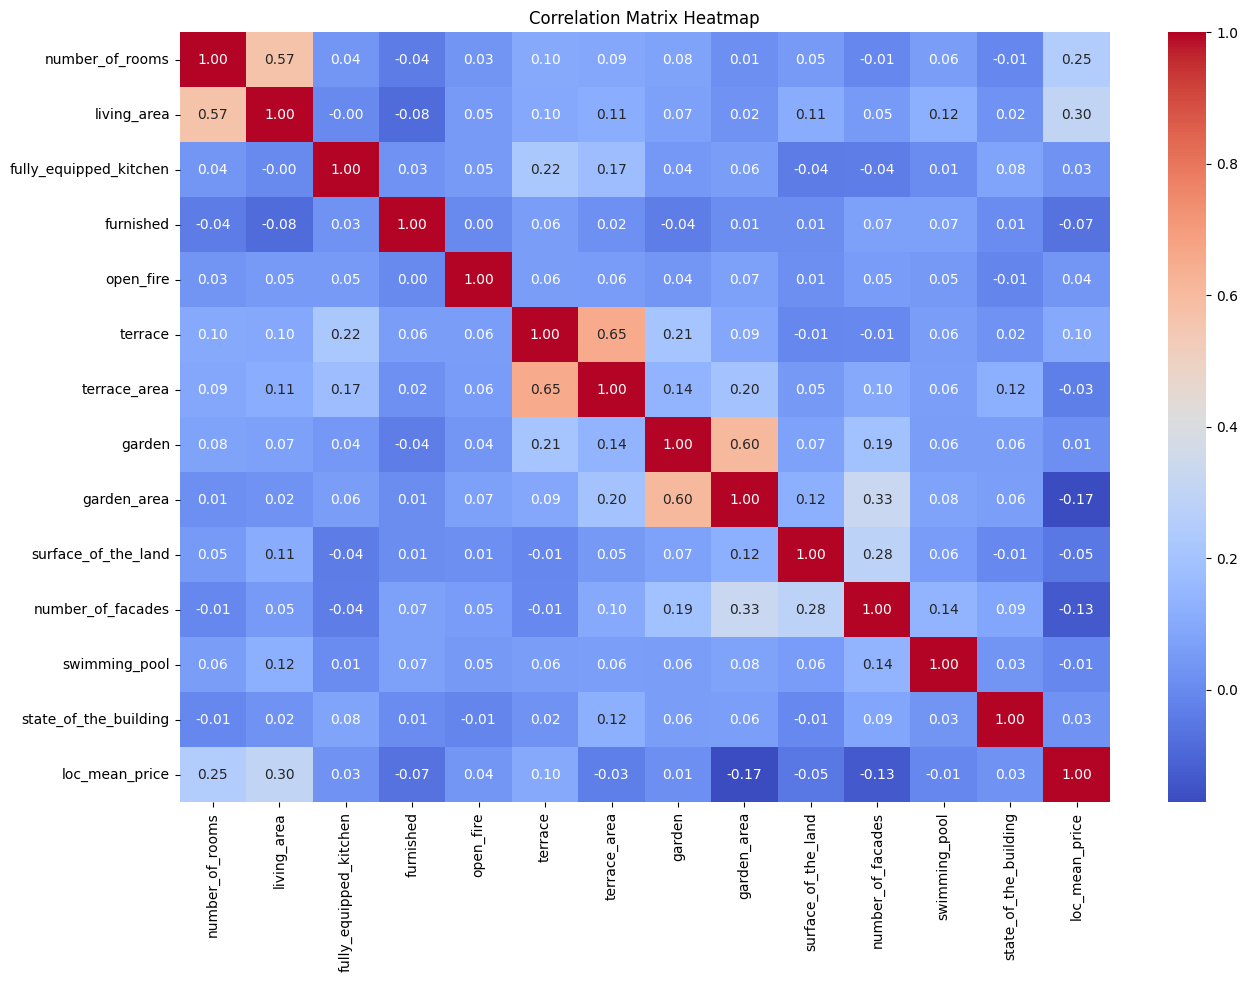

In [122]:
# corr heatmap
plt.figure(figsize=(15, 10))
sns.heatmap(X_numeric.corr(),
            annot= True,
            cmap = 'coolwarm',
            fmt='.2f')
plt.title('Correlation Matrix Heatmap')
plt.show()

In [123]:
X_numeric.head()

,number_of_rooms,living_area,fully_equipped_kitchen,furnished,open_fire,terrace,terrace_area,garden,garden_area,surface_of_the_land,number_of_facades,swimming_pool,state_of_the_building,loc_mean_price
125,4,218,1,0,0,1,21,1,192,20730,3,0,1,375348.303962
2478,7,426,1,0,0,0,0,0,0,225,2,0,2,412903.205857
7613,2,124,1,0,0,1,11,1,14,85,2,0,3,300848.162017
7387,2,50,3,0,0,1,20,1,200,270,4,0,2,276304.893081
3711,4,162,1,0,0,1,20,1,200,740,4,1,2,307413.180503


In [124]:
# checking VIF / multicollinearity

for col in X_numeric.columns:
    if X_numeric[col].dtype == 'bool':
        X_numeric[col] = X_numeric[col].astype(float)
    elif X_numeric[col].dtype.name == 'Int64':
        X_numeric[col] = X_numeric[col].astype(float)

vif_data = pd.DataFrame()
X_numeric_const = add_constant(X_numeric)
vif_data["feature"] = X_numeric_const.columns
vif_data["VIF"] = [variance_inflation_factor(X_numeric_const.values, i) 
                   for i in range(X_numeric_const.shape[1])]
vif_data = vif_data.sort_values(by="VIF", ascending=False)
print(vif_data)

                   feature        VIF
0                    const  36.800457
6                  terrace   1.958216
7             terrace_area   1.912992
9              garden_area   1.834447
8                   garden   1.698481
2              living_area   1.606728
1          number_of_rooms   1.500687
11       number_of_facades   1.250606
14          loc_mean_price   1.211813
10     surface_of_the_land   1.104511
3   fully_equipped_kitchen   1.070750
12           swimming_pool   1.044659
13   state_of_the_building   1.039346
4                furnished   1.030392
5                open_fire   1.016017


In [125]:
# checking correlation with price
corr_with_target = X_numeric[num_cols].corrwith(y_train)
print(corr_with_target.sort_values(ascending=False))

loc_mean_price            0.686784
living_area               0.581643
number_of_rooms           0.427521
state_of_the_building     0.237209
terrace                   0.180638
surface_of_the_land       0.153123
terrace_area              0.148185
swimming_pool             0.145136
garden                    0.107167
fully_equipped_kitchen    0.082328
number_of_facades         0.081233
open_fire                 0.073337
garden_area              -0.013062
furnished                -0.055684
dtype: float64


### 2.6. Log-transformations (skew) ###

In [ ]:
# visualisation of the distribution and skewness
skewed_cols = ['living_area', 'surface_of_the_land', 'garden_area', 'terrace_area']

for col in skewed_cols:
    func_log_graph(X_train, col)

In [ ]:
# checking skew for 'y'
skew_before = skew(y_train)
skew_after = skew(np.log1p(y_train))

print(f"Price skew before log1p: {skew_before:.2f}")
print(f"Price skew after log1p: {skew_after:.2f}")

### 2.7. Standatisation of X ###

In [ ]:
# Decided to do it inside Pipeline of multinomial regression

# STEP 3: MODEL SELECTION #

### 3.1. Selection of regression type ###

In [126]:

def check_linear_relationships(X, y):
    numeric_cols = X.select_dtypes(include=['float64','int64','Int64']).columns
    bool_cols = X.select_dtypes(include=['bool']).columns

    formatter = ticker.FuncFormatter(lambda x, p: format(int(x), ','))

    print("=== Numeric variables ===")
    for col in numeric_cols:
        plt.figure(figsize=(6,4))
        plt.scatter(X[col], y, alpha=0.3)
        plt.xlabel(col)
        plt.ylabel("price")
        plt.title(f"{col} vs price")
        
        plt.gca().yaxis.set_major_formatter(formatter)
        
        plt.show()
    
    print("=== Bool variables ===")
    for col in bool_cols:
        plt.figure(figsize=(6,4))


        sns.boxplot(x=X[col], y=y)
        
        plt.xlabel(col)
        plt.ylabel("price")
        plt.title(f"{col} vs price (bool)")
        
        plt.gca().yaxis.set_major_formatter(formatter)
        plt.show()
        
        mean_prices = y.groupby(X[col]).mean()
        print(f"--- {col} — average prices ---")
        for val, price in mean_prices.items():
            print(f"{val}: {price:,.0f}")
        print()

=== Numeric variables ===


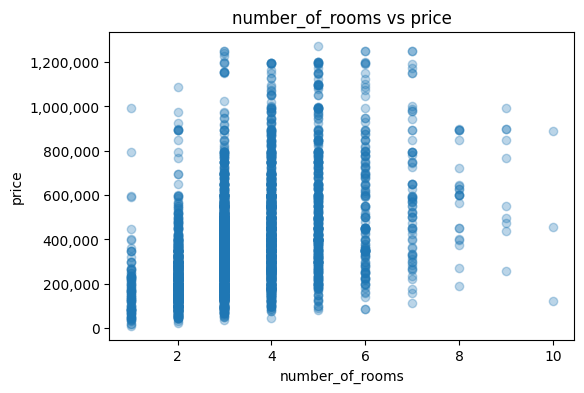

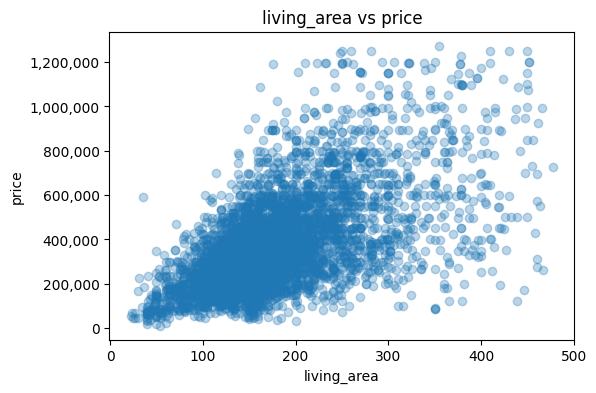

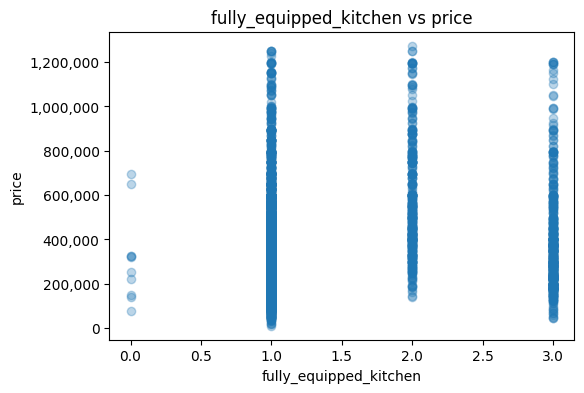

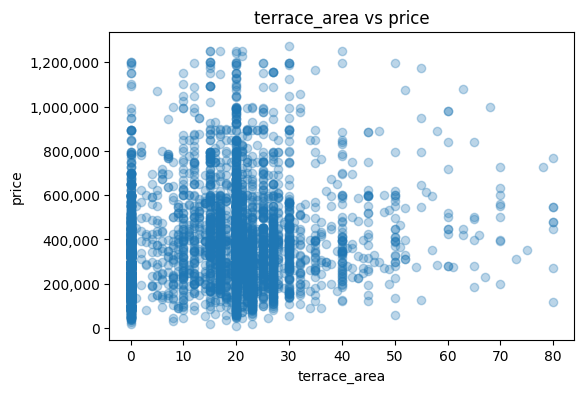

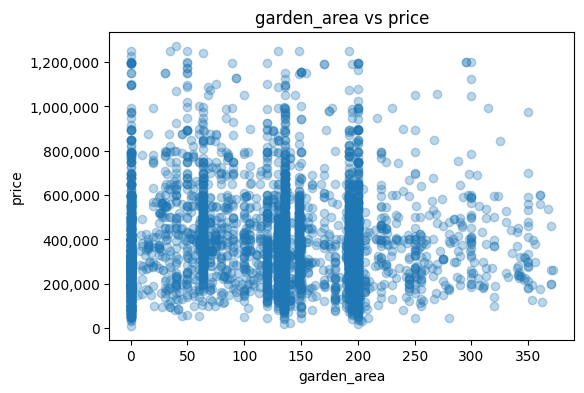

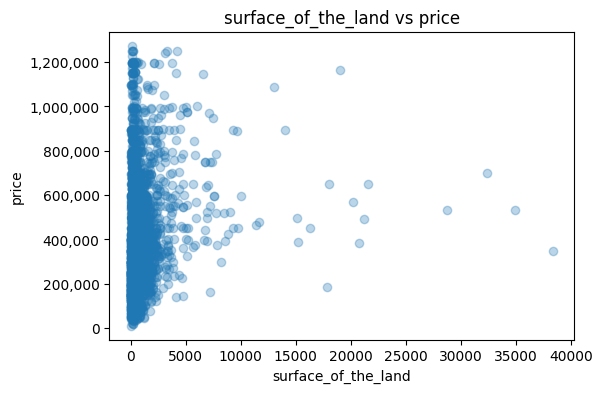

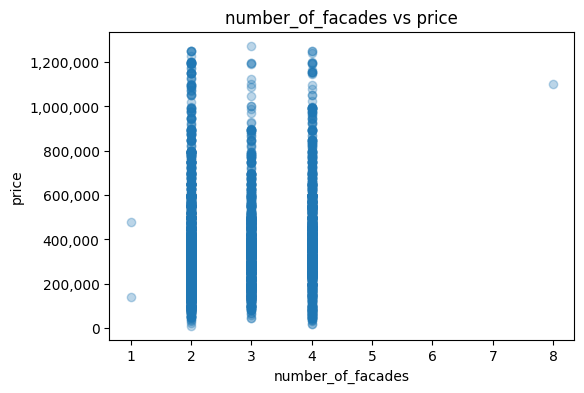

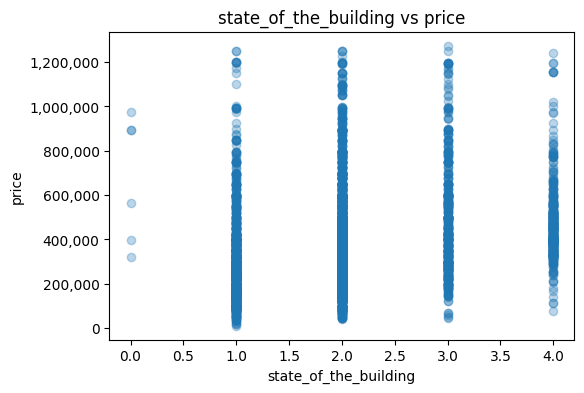

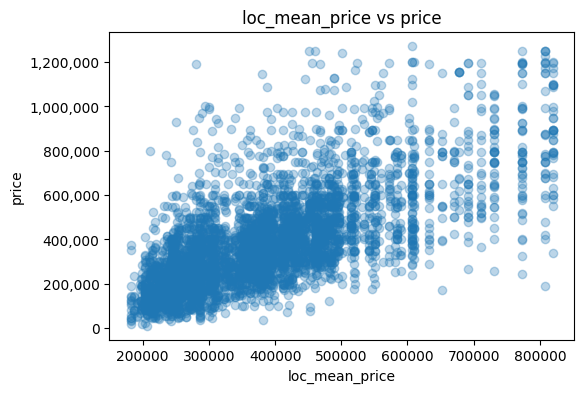

=== Bool variables ===


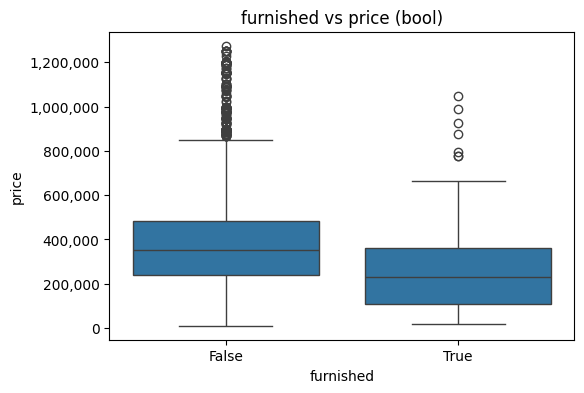

--- furnished — average prices ---
False: 388,600
True: 295,382



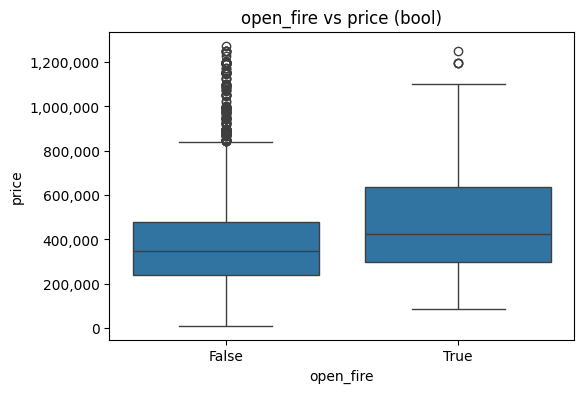

--- open_fire — average prices ---
False: 384,544
True: 484,783



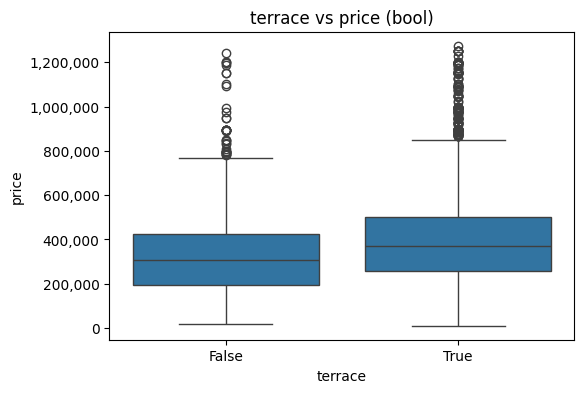

--- terrace — average prices ---
False: 329,167
True: 412,784



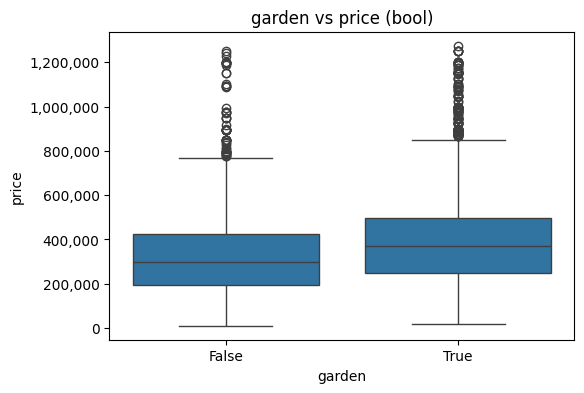

--- garden — average prices ---
False: 343,402
True: 399,064



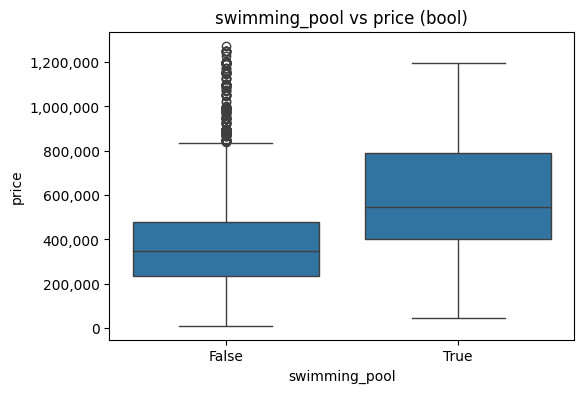

--- swimming_pool — average prices ---
False: 382,107
True: 581,328



In [127]:
check_linear_relationships(X_train, y_train)

# STEP 4: APPLYING A MODEL #

### 4.1. One-hot encoding ###

In [128]:
# Drop the columns we don't need for the analysis now
cols_to_drop = ['city', 'type_of_sale', 'type_of_property']
X_train = X_train.drop(columns=cols_to_drop)
X_test = X_test.drop(columns=cols_to_drop)

# One-hot for categorical data (only some for now)
categorical_cols = ['subtype_of_property']
X_train_encoded = pd.get_dummies(X_train, columns=categorical_cols, drop_first=True)
X_test_encoded  = pd.get_dummies(X_test, columns=categorical_cols, drop_first=True)

X_test_encoded = X_test_encoded.reindex(columns=X_train_encoded.columns, fill_value=0)

# Bool -> Int64
bool_cols = X_train_encoded.select_dtypes(include='bool').columns
X_train_encoded[bool_cols] = X_train_encoded[bool_cols].astype('Int64')
X_test_encoded[bool_cols]  = X_test_encoded[bool_cols].astype('Int64')

In [129]:
X_train_encoded.info()

<class 'pandas.DataFrame'>
Index: 4589 entries, 125 to 1742
Data columns (total 24 columns):
 #   Column                              Non-Null Count  Dtype  
---  ------                              --------------  -----  
 0   zip_code                            4589 non-null   string 
 1   province                            4589 non-null   string 
 2   region                              4589 non-null   string 
 3   number_of_rooms                     4589 non-null   Int64  
 4   living_area                         4589 non-null   Int64  
 5   fully_equipped_kitchen              4589 non-null   Int64  
 6   furnished                           4589 non-null   Int64  
 7   open_fire                           4589 non-null   Int64  
 8   terrace                             4589 non-null   Int64  
 9   terrace_area                        4589 non-null   Int64  
 10  garden                              4589 non-null   Int64  
 11  garden_area                         4589 non-null   Int64

In [130]:
X_test_encoded.info()

<class 'pandas.DataFrame'>
Index: 1148 entries, 1222 to 9465
Data columns (total 24 columns):
 #   Column                              Non-Null Count  Dtype  
---  ------                              --------------  -----  
 0   zip_code                            1148 non-null   string 
 1   province                            1148 non-null   string 
 2   region                              1148 non-null   string 
 3   number_of_rooms                     1148 non-null   Int64  
 4   living_area                         1148 non-null   Int64  
 5   fully_equipped_kitchen              1148 non-null   Int64  
 6   furnished                           1148 non-null   Int64  
 7   open_fire                           1148 non-null   Int64  
 8   terrace                             1148 non-null   Int64  
 9   terrace_area                        1148 non-null   Int64  
 10  garden                              1148 non-null   Int64  
 11  garden_area                         1148 non-null   Int6

### 4.2. Training a Model ###

In [ ]:
# # Simple linear regression
# model = LinearRegression()

# model.fit(X_train_encoded, y_train)
# train_score = model.score(X_train_encoded, y_train)
# print(f'Train R-sqr: {train_score:,.3f}')

# y_pred = model.predict(X_test_encoded)

# r2   = r2_score(y_test, y_pred)
# mae  = mean_absolute_error(y_test, y_pred)
# mse  = mean_squared_error(y_test, y_pred)
# rmse = np.sqrt(mse)
# print('\n-----TEST METRICS-----')
# print(f"Test R-sqr: {r2:.3f}")
# print(f"MAE: {mae:,.0f}")
# print(f"MSE: {mse:,.0f}")
# print(f"RMSE: {rmse:,.0f}")

### 4.3. Coefficients ###

In [ ]:
# coefficients = pd.DataFrame({
#     'feature': X_train_encoded.columns,
#     'beta': model.coef_
# })

# coefficients = coefficients.sort_values(by='beta', ascending=False)
# print(f'Simple linear regression interceptotor: {model.intercept_:,.2f}')
# print(f'\nSimple linear regression coefficients: \n{round(coefficients, 2)}')

In [ ]:
# # NEW MODEL - ARGHHHH !!!! 
# y_train_log = np.log1p(y_train)
# y_test_log = np.log1p(y_test)

# model_log = LinearRegression()

# model_log.fit(X_train_encoded, y_train_log)

# y_pred_log = model_log.predict(X_test_encoded)

# y_pred = np.expm1(y_pred_log)

# r2 = r2_score(y_test, y_pred)
# mae = mean_absolute_error(y_test, y_pred)
# mse = mean_squared_error(y_test, y_pred)
# rmse = np.sqrt(mse)

# print("R-sqr:", round(r2,3))
# print("MAE:", round(mae))
# print("MSE:", round(mse))
# print("RMSE:", round(rmse))


In [ ]:
X_train_encoded.columns

In [ ]:
# # Polinomial Regression
# numeric_cols = ['number_of_rooms', 'living_area', 'terrace_area', 'garden_area', 
#                 'surface_of_the_land', 'state_of_the_building']


# passthrough_cols = ['fully_equipped_kitchen', 'furnished', 
#                     'open_fire', 'terrace', 'garden', 'swimming_pool',
#                     'region_Flanders', 'region_Wallonia', 'subtype_of_property_chalet',
#                     'subtype_of_property_cottage', 'subtype_of_property_mansion',
#                     'subtype_of_property_master-house','subtype_of_property_mixed-building',
#                     'subtype_of_property_residence', 'subtype_of_property_villa']

# degree = 2

# preprocessor = ColumnTransformer([
#     ('num', Pipeline([
#         ('scaler', StandardScaler()),
#         ('poly', PolynomialFeatures(degree=degree, include_bias=False))
#     ]), numeric_cols),
#     ('passthrough', 'passthrough', passthrough_cols)
# ])

# pipeline = Pipeline([
#     ('preprocessor', preprocessor),
#     ('regressor', LinearRegression())])

# pipeline.fit(X_train_encoded, y_train)
# r2_train = r2_score(y_train, pipeline.predict(X_train_encoded))
# print(f'Train R-sqr: {r2_train:,.4f}')

# y_pred = pipeline.predict(X_test_encoded)

# r2_test = r2_score(y_test, y_pred)
# mae = mean_absolute_error(y_test, y_pred)
# mse = mean_squared_error(y_test, y_pred)
# rmse = np.sqrt(mse)
# print('\n-----TEST METRICS-----')
# print(f"Test R-sqr: {r2_test:,.4f}")
# print(f"MAE: {mae:,.0f}")
# print(f"MSE: {mse:,.0f}")
# print(f"RMSE: {rmse:,.0f}")


In [ ]:

# reg = pipeline.named_steps['regressor']

# poly = pipeline.named_steps['preprocessor'].named_transformers_['num'].named_steps['poly']

# numeric_feature_names = poly.get_feature_names_out(numeric_cols)

# all_feature_names = list(numeric_feature_names) + passthrough_cols

# coef_df = pd.DataFrame({
#     'feature': all_feature_names,
#     'coef': reg.coef_
# })

# coef_df['abs_coef'] = coef_df['coef'].abs()
# coef_df = coef_df.sort_values(by='abs_coef', ascending=False).drop(columns='abs_coef')
# print('-----POLYNOMIAL REGRESSION COEFFICIENTS-----')
# print(coef_df)

In [ ]:
# top10_coef = coef_df.copy()
# top10_coef['abs_coef'] = top10_coef['coef'].abs()
# top10_coef = top10_coef.sort_values(by='abs_coef', ascending=False).head(10)

# plt.figure(figsize=(10,6))
# plt.barh(top10_coef['feature'][::-1], top10_coef['coef'][::-1], color='teal')
# plt.xlabel("Coefficient value")
# plt.title("Top 10 features by coefficient magnitude (Polynomial Regression, degree=2)")
# plt.show()

#### Ridge, Lasso, OLS, Polynomial ####

In [ ]:
# # Остальные (регионы, типы) просто масштабируем
# # other_features = [col for col in X_train_encoded.columns if col not in numeric_cols]

# preprocessor = ColumnTransformer(
#     transformers=[
#         ('num_poly', Pipeline([
#             ('scaler', StandardScaler()),
#             ('poly', PolynomialFeatures(include_bias=False))
#         ]), numeric_cols),
        
#         ('just_scale', StandardScaler(), passthrough_cols)
#     ]
# )

# # Pipeline
# pipe = Pipeline([
#     ('preprocessor', preprocessor),
#     ('model', Ridge())
# ])

# # Grid Search
# param_grid = [
#     {
#         'preprocessor__num_poly__poly__degree': [1, 2],
#         'model': [LinearRegression()]
#     },
#     {
#         'preprocessor__num_poly__poly__degree': [1, 2],
#         'model': [Ridge(), Lasso(max_iter=20000)],
#         'model__alpha': [0.1, 1.0, 10.0, 100.0]
#     }
# ]

# #X_train_encoded, X_test_encoded = X_train_encoded.align(X_test_encoded, join='left', axis=1, fill_value=0)
# X_test_encoded = X_test_encoded.reindex(columns=X_train_encoded.columns, fill_value=0)

# grid = GridSearchCV(pipe, param_grid, cv=5, scoring='r2', n_jobs=-1)
# grid.fit(X_train_encoded, y_train)

# # results
# best_model = grid.best_estimator_
# y_pred = best_model.predict(X_test_encoded)

# print(f"--- BEST CONFIGURATION ---")
# print(f"Model: {grid.best_params_['model']}")
# print(f"Polynom degree: {grid.best_params_.get('preprocessor__num_poly__poly__degree', 1)}")
# print(f"Alpha: {grid.best_params_.get('model__alpha', 'N/A')}")

# print(f'Train R-sqr: {r2_score(y_train, best_model.predict(X_train_encoded)):,.4f}')

# print(f"\n--- TEST METRICS ---")
# print(f"R2: {r2_score(y_test, y_pred):.4f}")
# print(f"MAE: {mean_absolute_error(y_test, y_pred):,.0f}")

#### RandomForest ####

In [ ]:
# preprocessor = ColumnTransformer(
#     transformers=[
#         ('num', StandardScaler(), numeric_cols),
#         ('pass', 'passthrough', passthrough_cols)
#     ]
# )

# pipe = Pipeline([
#     ('preprocessor', preprocessor),
#     ('model', RandomForestRegressor(random_state=42))
# ])


# param_grid = {
#     'model__n_estimators': [100, 200],
#     'model__max_depth': [10, 20, None],
#     'model__min_samples_leaf': [1, 2, 4]
# }

# X_test_encoded = X_test_encoded.reindex(columns=X_train_encoded.columns, fill_value=0)

# grid = GridSearchCV(pipe, param_grid, cv=5, scoring='r2', n_jobs=-1, verbose=1)
# grid.fit(X_train_encoded, y_train)

# best_model = grid.best_estimator_
# y_pred = best_model.predict(X_test_encoded)

# print(f"--- RANDOM FOREST ---")
# print(f"Best parameters: {grid.best_params_}")
# print(f"Train R-sqr: {grid.best_score_:.4f}")

# print(f"\n----- TEST METRICS -----")
# print(f"Test R-sqr: {r2_score(y_test, y_pred):.4f}")
# print(f"MAE: {mean_absolute_error(y_test, y_pred):,.0f}")

# importances = best_model.named_steps['model'].feature_importances_
# features = numeric_cols + passthrough_cols
# feature_importance_df = pd.DataFrame({'feature': features, 'importance': importances}).sort_values(by='importance', ascending=False)

# print("\n----- TOP-5 IMPORTANT METRICS -----")
# print(feature_importance_df.head(5))

#### XGBoost ####

In [ ]:
# preprocessor = ColumnTransformer(
#     transformers=[
#         ('num', StandardScaler(), numeric_cols),
#         ('pass', 'passthrough', passthrough_cols)
#     ]
# )

# pipe = Pipeline([
#     ('preprocessor', preprocessor),
#     ('model', XGBRegressor(random_state=42, n_jobs=-1, verbosity=0))
# ])

# param_grid = {
#     'model__n_estimators': [500, 1000],
#     'model__learning_rate': [0.01, 0.05, 0.1],
#     'model__max_depth': [3, 5, 7],
#     'model__subsample': [0.8, 1.0]
# }

# grid = GridSearchCV(pipe, param_grid, cv=5, scoring='r2', n_jobs=-1, verbose=1)
# grid.fit(X_train_encoded, y_train)


# best_model = grid.best_estimator_
# y_pred = best_model.predict(X_test_encoded)

# print(f"--- XGBOOST RESULTS ---")
# print(f"Best parameters: {grid.best_params_}")
# print(f"Train R-sqr: {grid.best_score_:.4f}")

# print(f"\n--- TEST METRICS ---")
# print(f"Test R-sqr: {r2_score(y_test, y_pred):.4f}")
# print(f"MAE: {mean_absolute_error(y_test, y_pred):,.0f}")

# importances = best_model.named_steps['model'].feature_importances_
# features = numeric_cols + passthrough_cols
# feature_importance_df = pd.DataFrame({'feature': features, 'importance': importances}).sort_values(by='importance', ascending=False)

# print("\n--- TOP-5 FEATURES (XGBoost) ---")
# print(feature_importance_df.head(5))

#### ALL MODELS ####

In [131]:
X_train_encoded.shape

(4589, 24)

In [132]:
X_train_encoded.info()

<class 'pandas.DataFrame'>
Index: 4589 entries, 125 to 1742
Data columns (total 24 columns):
 #   Column                              Non-Null Count  Dtype  
---  ------                              --------------  -----  
 0   zip_code                            4589 non-null   string 
 1   province                            4589 non-null   string 
 2   region                              4589 non-null   string 
 3   number_of_rooms                     4589 non-null   Int64  
 4   living_area                         4589 non-null   Int64  
 5   fully_equipped_kitchen              4589 non-null   Int64  
 6   furnished                           4589 non-null   Int64  
 7   open_fire                           4589 non-null   Int64  
 8   terrace                             4589 non-null   Int64  
 9   terrace_area                        4589 non-null   Int64  
 10  garden                              4589 non-null   Int64  
 11  garden_area                         4589 non-null   Int64

##### Running a number of models to find the best (Poly (degree 1, 2), RandomForest, XGBoost) #####

In [133]:
    # =================================================================
    # BLOCK 1: INITIAL MODEL SELECTION (BASELINE)
    # =================================================================
def best_model_base(X_train_encoded, y_train, X_test_encoded, y_test):
    """
    Function, that runs on the split dataframe and chooses the best evaluation model via GridSearchCV and returns lots of metrics
    Models: 
        Simple Linear Rregression (degree = 1)
        Polynomial Regression (degree = 2)
        Regularized Regressions (Lasso (max_inter = 20000), Ridge(): 
            'poly__degree': [1, 2]
            'alpha': [0.1, 1.0, 10.0, 50.0, 100.0, 1000.0, 5000.0])
        RandomForest Regressor:
            'n_estimators': [100, 200]
            'max_depth': [10, 20, None]
            'min_samples_leaf': [1, 2, 4])
        XGBoost Regressor:
            'n_estimators': [500, 1000]
            'learning_rate': [0.001, 0.01, 0.05, 0.1]
            'max_depth': [3, 5, 7]
            'min_child_weight': [1, 3, 5]
            'subsample': [0.8, 1.0]

    Args: 
        X_train_encoded (pd.DataFrame): X_train 'feature' values set encoded with One-Hot Encoder
        y_train (pd.Series): y_train 'target' values
        X_test_encoded (pd.DataFrame): X_test 'feature' values set encoded with One-Hot Encoder
        y_test (pd.Series): y_test 'target' values

    Returns:
        best_model_initial (sklearn.pipeline.Pipeline): best model chosen by metric (scoring)
        feature_names_base (List of strings): list of best features selected by the model
        grid.best_score_: R-sqr score of the model after cross-validation (cv)
        r2_base: R-sqr score of the model running on the 'test' data
        adj_r2_base: a modified version of Rsqr that adjusts for the number of predictors in
            a regression model, penalizing the inclusion of unnecessary variables. Formula:
            R2_adj = 1 - (1 - Rsqr) * (sample size - 1)/(sample size - number of features - 1)
        MAE_test: Mean Absolute Error of the model on the 'test'
        k_base: number of model features
        
    """
    # Define geo-columns, not to be included into the model
    geo_text_cols = ['zip_code', 'province', 'region']

    # Define your initial numeric features
    numeric_cols = ['number_of_rooms', 'living_area', 'terrace_area', 'garden_area', 'state_of_the_building', 'surface_of_the_land', 'loc_mean_price']

    # Define passthrough columns (categorical/binary)
    passthrough_cols = [col for col in X_train_encoded.columns if col not in numeric_cols and col not in geo_text_cols]

    # Preprocessing Pipeline
    preprocessor = ColumnTransformer(
        transformers=[
            ('num_poly', Pipeline([
                ('scaler', StandardScaler()),
                ('poly', PolynomialFeatures(include_bias=False))
            ]), numeric_cols),
            ('just_scale', StandardScaler(), passthrough_cols)
        ]
    )

    # Main Pipeline
    pipe = Pipeline([
        ('preprocessor', preprocessor),
        ('model', LinearRegression()) 
    ])

    # Param grid for various models
    param_grid = [
        {'preprocessor__num_poly__poly__degree': [1, 2], 'model': [LinearRegression()]},
        {
            'preprocessor__num_poly__poly__degree': [1, 2],
            'model': [Lasso(max_iter=20000), Ridge()],
            'model__alpha': [0.1, 1.0, 10.0, 50.0, 100.0, 1000.0, 5000.0]
        },
        {
            'preprocessor__num_poly__poly__degree': [1],
            'model': [RandomForestRegressor(random_state=42)],
            'model__n_estimators': [100, 200],
            'model__max_depth': [10, 20, None],
            'model__min_samples_leaf': [1, 2, 4]
        },
        {
            'preprocessor__num_poly__poly__degree': [1],
            'model': [XGBRegressor(random_state=42, n_jobs=-1, verbosity=0)],
            'model__n_estimators': [500, 1000],
            'model__learning_rate': [0.001, 0.01, 0.05, 0.1],
            'model__max_depth': [3, 5, 7],
            'model__min_child_weight': [1, 3, 5],
            'model__subsample': [0.8, 1.0]
        }
    ]

    # Ensure test set columns match training set
    X_test_encoded = X_test_encoded.reindex(columns=X_train_encoded.columns, fill_value=0)

    # Run GridSearchCV
    kf = KFold(n_splits=5, shuffle=True, random_state=42) # Kansas city shuffle ;)
    grid = GridSearchCV(pipe, param_grid, cv=kf, scoring='r2', n_jobs=-1, verbose=1)
    grid.fit(X_train_encoded, y_train)

    # --- BASELINE METRICS CALCULATION ---
    best_model_initial = grid.best_estimator_
    y_pred_base = best_model_initial.predict(X_test_encoded)

    # Get feature names to count them correctly (including polynomials)
    feature_names_base = best_model_initial.named_steps['preprocessor'].get_feature_names_out()
    r2_best_cv = grid.best_score_
    r2_base = r2_score(y_test, y_pred_base)
    n_base = len(y_test)
    k_base = len(feature_names_base)
    adj_r2_base = 1 - (1 - r2_base) * (n_base - 1) / (n_base - k_base - 1)
    MAE_base = mean_absolute_error(y_test, y_pred_base)


    print(f"\n{'='*40}")
    print(f"BASELINE RESULTS (All Features)")
    print(f"Winner Model: {grid.best_params_['model']}")
    print(f"Best CV R2: {r2_best_cv:.4f}")
    print(f"Test R2: {r2_base:.4f}")
    print(f"Test Adjusted R2: {adj_r2_base:.4f}")
    print(f"Test MAE: {MAE_base:,.0f} €")
    print(f"Final Feature Count: {k_base}")
    print(f"{'='*40}")

    return best_model_initial, feature_names_base, r2_best_cv, r2_base, adj_r2_base, MAE_base, k_base

In [134]:
best_model_initial_1, feature_names_base_1, r2_best_cv_1, r2_base_1, adj_r2_base_1, MAE_base_1, k_base_1 = best_model_base(X_train_encoded, y_train, X_test_encoded, y_test)
print(best_model_initial_1)
print(feature_names_base_1)
print(r2_best_cv_1)
print(r2_base_1)
print(adj_r2_base_1)
print(MAE_base_1)
print(k_base_1)

Fitting 5 folds for each of 192 candidates, totalling 960 fits

BASELINE RESULTS (All Features)
Winner Model: XGBRegressor(base_score=None, booster=None, callbacks=None,
             colsample_bylevel=None, colsample_bynode=None,
             colsample_bytree=None, device=None, early_stopping_rounds=None,
             enable_categorical=False, eval_metric=None, feature_types=None,
             feature_weights=None, gamma=None, grow_policy=None,
             importance_type=None, interaction_constraints=None,
             learning_rate=None, max_bin=None, max_cat_threshold=None,
             max_cat_to_onehot=None, max_delta_step=None, max_depth=None,
             max_leaves=None, min_child_weight=None, missing=nan,
             monotone_constraints=None, multi_strategy=None, n_estimators=None,
             n_jobs=-1, num_parallel_tree=None, ...)
Best CV R2: 0.7659
Test R2: 0.7518
Test Adjusted R2: 0.7472
Test MAE: 75,217 €
Final Feature Count: 21
Pipeline(steps=[('preprocessor',
      

In [ ]:
# # =================================================================
# # BLOCK 1: INITIAL MODEL SELECTION (BASELINE)
# # =================================================================

# # 1. Define your initial numeric features
# #numeric_cols = ['number_of_rooms', 'living_area', 'terrace_area', 'garden_area', 'state_of_the_building']
# numeric_cols = ['number_of_rooms', 'living_area', 'terrace_area', 'garden_area', 'state_of_the_building', 'surface_of_the_land', 'loc_mean_price']

# # Define passthrough columns (categorical/binary)
# passthrough_cols = [col for col in X_train_encoded.columns if col not in numeric_cols]

# # Preprocessing Pipeline
# preprocessor = ColumnTransformer(
#     transformers=[
#         ('num_poly', Pipeline([
#             ('scaler', StandardScaler()),
#             ('poly', PolynomialFeatures(include_bias=False))
#         ]), numeric_cols),
#         ('just_scale', StandardScaler(), passthrough_cols)
#     ]
# )

# # Main Pipeline
# pipe = Pipeline([
#     ('preprocessor', preprocessor),
#     ('model', LinearRegression()) 
# ])

# # Param grid for various models
# param_grid = [
#     {'preprocessor__num_poly__poly__degree': [1, 2], 'model': [LinearRegression()]},
#     {
#         'preprocessor__num_poly__poly__degree': [1, 2],
#         'model': [Lasso(max_iter=20000), Ridge()],
#         'model__alpha': [100.0, 1000.0, 5000.0]
#     },
#     {
#         'preprocessor__num_poly__poly__degree': [1],
#         'model': [RandomForestRegressor(random_state=42)],
#         'model__n_estimators': [100, 200],
#         'model__max_depth': [10, 20, None],
#         'model__min_samples_leaf': [1, 2, 4]
#     },
#     {
#         'preprocessor__num_poly__poly__degree': [1],
#         'model': [XGBRegressor(random_state=42, n_jobs=-1, verbosity=0)],
#         'model__n_estimators': [500, 1000],
#         'model__learning_rate': [0.01, 0.05, 0.1],
#         'model__max_depth': [3, 5, 7],
#         'model__subsample': [0.8, 1.0]
#     }
# ]

# # Ensure test set columns match training set
# X_test_encoded = X_test_encoded.reindex(columns=X_train_encoded.columns, fill_value=0)

# # Run GridSearchCV
# grid = GridSearchCV(pipe, param_grid, cv=5, scoring='r2', n_jobs=-1, verbose=1)
# grid.fit(X_train_encoded, y_train)

# # --- BASELINE METRICS CALCULATION ---
# best_model_initial = grid.best_estimator_
# y_pred_base = best_model_initial.predict(X_test_encoded)

# # Get feature names to count them correctly (including polynomials)
# feature_names_base = best_model_initial.named_steps['preprocessor'].get_feature_names_out()
# r2_base = r2_score(y_test, y_pred_base)
# n_base = len(y_test)
# k_base = len(feature_names_base)
# adj_r2_base = 1 - (1 - r2_base) * (n_base - 1) / (n_base - k_base - 1)

# print(f"\n{'='*40}")
# print(f"BASELINE RESULTS (All Features)")
# print(f"Winner Model: {grid.best_params_['model']}")
# print(f"Best CV R2: {grid.best_score_:.4f}")
# print(f"Test R2: {r2_base:.4f}")
# print(f"Test Adjusted R2: {adj_r2_base:.4f}")
# print(f"Test MAE: {mean_absolute_error(y_test, y_pred_base):,.0f} €")
# print(f"Final Feature Count: {k_base}")
# print(f"{'='*40}")

In [ ]:
#print(grid.best_score_)

In [ ]:
# import matplotlib.pyplot as plt

# residuals = y_test - y_pred

# plt.figure(figsize=(10, 6))
# plt.scatter(y_pred, residuals, alpha=0.5)
# plt.axhline(y=0, color='r', linestyle='--')
# plt.xlabel('y_pred')
# plt.ylabel('Error (Real - Predicted)')
# plt.title('XGBoost Error Analysis')
# plt.show()

### Feature selection ### 


In [ ]:
# corr heatmap
plt.figure(figsize=(15, 10))
sns.heatmap(X_train_encoded.corr(),
            annot= True,
            cmap = 'coolwarm',
            fmt='.2f')
plt.title('Correlation Matrix Heatmap')
plt.show()

In [ ]:
# vif_data = pd.DataFrame()
# X_train_encoded_const = add_constant(X_train_encoded)
# vif_data["feature"] = X_train_encoded_const.columns

# # need FLOAT to calculate metrics
# vif_data["VIF"] = [
#     variance_inflation_factor(X_train_encoded_const.astype(float).values, i) 
#     for i in range(X_train_encoded_const.shape[1])
# ]

# vif_data = vif_data.sort_values(by="VIF", ascending=False)
# print(vif_data)

In [ ]:
# # # What if we drop several columns (i.e. garden, terrace)

# # X_train_encoded = X_train_encoded.drop(columns=['garden', 'terrace', 'subtype_of_property_residence'])
# # X_test_encoded = X_test_encoded.drop(columns=['garden', 'terrace', 'subtype_of_property_residence'])

# X_train_encoded = X_train_encoded.drop(columns=['subtype_of_property_residence'])
# X_test_encoded = X_test_encoded.drop(columns=['subtype_of_property_residence'])

In [ ]:
# vif_data = pd.DataFrame()
# X_train_encoded_const = add_constant(X_train_encoded)
# vif_data["feature"] = X_train_encoded_const.columns

# # need FLOAT to calculate metrics
# vif_data["VIF"] = [
#     variance_inflation_factor(X_train_encoded_const.astype(float).values, i) 
#     for i in range(X_train_encoded_const.shape[1])
# ]

# vif_data = vif_data.sort_values(by="VIF", ascending=False)
# print(vif_data)

In [ ]:
# # =================================================================
# # BLOCK 2: VIF, RFECV, AND FINAL MODEL RUN
# # =================================================================

# # 1. VIF: Remove Multicollinearity
# X_train_float = X_train_encoded.astype(float)
# # Automatically drop columns with zero variance (all zeros/ones)
# constant_cols = [c for c in X_train_float.columns if X_train_float[c].nunique() <= 1]
# X_train_vif_input = X_train_float.drop(columns=constant_cols)

# X_const = add_constant(X_train_vif_input)
# vif_data = pd.DataFrame()
# vif_data["feature"] = X_const.columns
# vif_data["VIF"] = [variance_inflation_factor(X_const.values, i) for i in range(X_const.shape[1])]

# selected_vif_features = vif_data[vif_data["VIF"] < 10]["feature"].tolist()
# if 'const' in selected_vif_features: selected_vif_features.remove('const')

# # 2. RFECV: Feature Selection with XGBoost
# xgb_selector = XGBRegressor(n_estimators=100, learning_rate=0.05, max_depth=5, random_state=42, n_jobs=-1, verbosity=0)
# rfecv = RFECV(estimator=xgb_selector, step=1, cv=5, scoring='r2', n_jobs=-1)

# X_train_vif_filtered = X_train_vif_input[selected_vif_features]
# rfecv.fit(X_train_vif_filtered, y_train)

# final_features = X_train_vif_filtered.columns[rfecv.support_].tolist()

# # 3. Final Model Execution (Using winner architecture from Block 1)
# # Important: Update the lists based on final_features
# final_numeric_cols = [col for col in numeric_cols if col in final_features]
# final_passthrough_cols = [col for col in final_features if col not in final_numeric_cols]

# preprocessor_final = ColumnTransformer(
#     transformers=[
#         ('num_poly', Pipeline([
#             ('scaler', StandardScaler()),
#             ('poly', PolynomialFeatures(include_bias=False))
#         ]), final_numeric_cols),
#         ('just_scale', StandardScaler(), final_passthrough_cols)
#     ]
# )

# # Re-run GridSearch specifically on the optimized feature set
# final_pipe = Pipeline([
#     ('preprocessor', preprocessor_final),
#     ('model', LinearRegression()) # Placeholder, param_grid will swap this
# ])

# X_train_final = X_train_encoded[final_features]
# X_test_final = X_test_encoded[final_features]

# grid_final = GridSearchCV(final_pipe, param_grid, cv=5, scoring='r2', n_jobs=-1, verbose=1)
# grid_final.fit(X_train_final, y_train)

# # 4. FINAL RESULTS & COMPARISON
# best_model_final = grid_final.best_estimator_
# y_pred_final = best_model_final.predict(X_test_final)

# feature_names_final = best_model_final.named_steps['preprocessor'].get_feature_names_out()
# r2_final = r2_score(y_test, y_pred_final)
# n_final = len(y_test)
# k_final = len(feature_names_final)
# adj_r2_final = 1 - (1 - r2_final) * (n_final - 1) / (n_final - k_final - 1)

# print(f"\n{'='*40}")
# print(f"OPTIMIZED RESULTS (Reduced Features)")
# print(f"Winner Model: {grid_final.best_params_['model']}")
# print(f"Best CV R2: {grid_final.best_score_:.4f}")
# print(f"Test R2: {r2_final:.4f}")
# print(f"Test Adjusted R2: {adj_r2_final:.4f}")
# print(f"Test MAE: {mean_absolute_error(y_test, y_pred_final):,.0f} €")
# print(f"Final Feature Count: {k_final}")
# print(f"{'='*40}")

# # List all features used in the final model
# print("\n--- FINAL FEATURE LIST ---")
# for i, name in enumerate(feature_names_final, 1):
#     print(f"{i}. {name}")

In [135]:


def run_production_ready_block_2(X_train_encoded, y_train, X_test_encoded, y_test, best_model_initial, numeric_cols):
    print(f"\n--- Запуск Универсального Блока 2 ---")

    # 1. ОПРЕДЕЛЯЕМ ПОБЕДИТЕЛЯ И ЕГО ТИП
    # Достаем саму модель из Pipeline (последний шаг)
    winner_model_obj = best_model_initial.steps[-1][1]
    is_xgb = isinstance(winner_model_obj, XGBRegressor)
    
    print(f"Победитель Блока 1: {type(winner_model_obj).__name__}")

    # 2. ПОДГОТОВКА ДАННЫХ (Удаляем текст для математики)
    geo_text_cols = ['zip_code', 'province', 'region']
    X_train_math = X_train_encoded.drop(columns=geo_text_cols, errors='ignore').astype(float)
    # Удаляем колонки-константы (где только одно уникальное значение)
    constant_cols = [c for c in X_train_math.columns if X_train_math[c].nunique() <= 1]
    X_train_vif_input = X_train_math.drop(columns=constant_cols)

    # 3. АДАПТИВНЫЙ RFECV
    # Мы клонируем модель-победителя, чтобы использовать её же логику для отбора признаков
    if is_xgb:
        # Для XGBoost используем быстрые настройки для отбора
        selector_model = XGBRegressor(n_estimators=200, learning_rate=0.1, max_depth=5, random_state=42, n_jobs=-1)
    else:
        # Для линейных моделей (Lasso/Ridge) используем саму модель (они и так быстрые)
        selector_model = clone(winner_model_obj)

    print(f"Выполняю RFECV с использованием {type(selector_model).__name__}...")
    rfecv = RFECV(estimator=selector_model, step=1, cv=3, scoring='r2', n_jobs=-1)
    rfecv.fit(X_train_vif_input, y_train)

    final_features = X_train_vif_input.columns[rfecv.support_].tolist()
    print(f"Отобрано признаков: {len(final_features)}")

    # 4. ДИНАМИЧЕСКИЙ ГРИД-СЕРЧ (Param Grid)
    # Настраиваем сетку в зависимости от того, какая модель победила
    if is_xgb:
        b1_params = winner_model_obj.get_params()
        param_grid_final = [{
            'model': [XGBRegressor(random_state=42, n_jobs=-1)],
            'model__learning_rate': [b1_params.get('learning_rate', 0.05)],
            'model__n_estimators': [b1_params.get('n_estimators', 1000), b1_params.get('n_estimators', 1000) + 500],
            'model__max_depth': [d for d in [b1_params.get('max_depth', 5) + i for i in [-1, 0, 1]] if d > 0],
            'model__subsample': [b1_params.get('subsample', 1.0)]
        }]
    else:
        # Сетка для Lasso/Ridge/Linear
        param_grid_final = [{
            'model': [type(winner_model_obj)()],
            'model__alpha': [0.1, 1.0, 10.0, 50.0, 100.0] if hasattr(winner_model_obj, 'alpha') else [None]
        }]

    # 5. ФИНАЛЬНОЕ ОБУЧЕНИЕ
    final_numeric_cols = [col for col in numeric_cols if col in final_features]
    final_passthrough_cols = [col for col in final_features if col not in final_numeric_cols]

    preprocessor_final = ColumnTransformer(transformers=[
        ('num_poly', Pipeline([
            ('scaler', StandardScaler()),
            ('poly', PolynomialFeatures(degree=1, include_bias=False))
        ]), final_numeric_cols),
        ('just_scale', StandardScaler(), final_passthrough_cols)
    ])

    final_pipe = Pipeline([('preprocessor', preprocessor_final), ('model', winner_model_obj)])
    
    grid_final = GridSearchCV(final_pipe, param_grid_final, cv=5, scoring='r2', n_jobs=-1)
    grid_final.fit(X_train_encoded[final_features], y_train)

    # 6. МЕТРИКИ (С возвращением Adjusted R2)
    best_model_final = grid_final.best_estimator_
    y_pred = best_model_final.predict(X_test_encoded[final_features])
    
    # Расчет метрик
    r2_final = r2_score(y_test, y_pred)
    mae_final = mean_absolute_error(y_test, y_pred)
    
    # Извлекаем финальное количество признаков (после всех трансформаций)
    feature_names_final = best_model_final.named_steps['preprocessor'].get_feature_names_out()
    n_samples = len(y_test)
    k_features = len(feature_names_final)
    
    # Формула Adjusted R2
    # Защита от деления на ноль, если признаков вдруг стало больше, чем строк
    if n_samples > k_features + 1:
        adj_r2_final = 1 - (1 - r2_final) * (n_samples - 1) / (n_samples - k_features - 1)
    else:
        adj_r2_final = float('nan')

    print(f"\n{'='*40}")
    print(f"ФИНАЛЬНЫЙ РЕЗУЛЬТАТ (Адаптивная модель)")
    print(f"Победитель: {type(best_model_final.named_steps['model']).__name__}")
    print(f"Test R2: {r2_final:.4f}")
    print(f"Test Adjusted R2: {adj_r2_final:.4f}")
    print(f"Test MAE: {mae_final:,.0f} €")
    print(f"Количество признаков (k): {k_features}")
    print(f"{'='*40}")

    return best_model_final, final_features, r2_final, adj_r2_final, mae_final

In [136]:
# Задаем список базовых числовых колонок (те, что были в Блоке 1)
numeric_cols = [
    'number_of_rooms', 'living_area', 'terrace_area', 'garden_area', 
    'state_of_the_building', 'surface_of_the_land', 'loc_mean_price'
]

# Запускаем универсальный Блок 2
best_model_final, final_features, r2_f, adj_r2_f, mae_f = run_production_ready_block_2(
    X_train_encoded, 
    y_train, 
    X_test_encoded, 
    y_test, 
    best_model_initial_1, # Объект из Блока 1
    numeric_cols
)


--- Запуск Универсального Блока 2 ---
Победитель Блока 1: XGBRegressor
Выполняю RFECV с использованием XGBRegressor...
Отобрано признаков: 20

ФИНАЛЬНЫЙ РЕЗУЛЬТАТ (Адаптивная модель)
Победитель: XGBRegressor
Test R2: 0.7558
Test Adjusted R2: 0.7515
Test MAE: 74,197 €
Количество признаков (k): 20


In [137]:
# 1. Достаем признаки из первой модели (Блок 1)
names_b1 = best_model_initial_1.named_steps['preprocessor'].get_feature_names_out()

# 2. Достаем признаки из второй модели (Блок 2)
names_b2 = best_model_final.named_steps['preprocessor'].get_feature_names_out()

# 3. Находим разницу
dropped_features = set(names_b1) - set(names_b2)
added_features = set(names_b2) - set(names_b1)

print(f"Удаленные признаки: {dropped_features}")
print(f"Новые признаки: {added_features}")

Удаленные признаки: {'just_scale__furnished'}
Новые признаки: set()


### Residual Plot / Prediction Error Plot ###

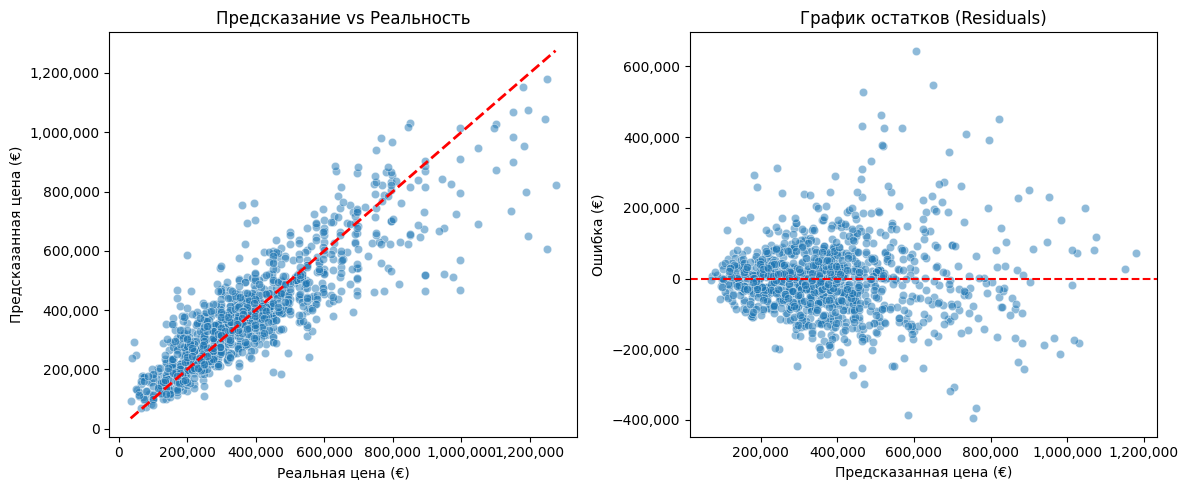

In [138]:
def plot_model_performance(y_test, y_pred):
    residuals = y_test - y_pred
    
    plt.figure(figsize=(12, 5))
    
    # Настройка форматтера: ставим запятую как разделитель тысяч
    formatter = ticker.StrMethodFormatter('{x:,.0f}')
    
    # 1. График: Предсказание vs Реальность
    ax1 = plt.subplot(1, 2, 1)
    sns.scatterplot(x=y_test, y=y_pred, alpha=0.5)
    plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], '--r', lw=2)
    plt.title('Предсказание vs Реальность')
    plt.xlabel('Реальная цена (€)')
    plt.ylabel('Предсказанная цена (€)')
    
    # Применяем форматтер к обеим осям первого графика
    ax1.xaxis.set_major_formatter(formatter)
    ax1.yaxis.set_major_formatter(formatter)
    
    # 2. График остатков
    ax2 = plt.subplot(1, 2, 2)
    sns.scatterplot(x=y_pred, y=residuals, alpha=0.5)
    plt.axhline(y=0, color='r', linestyle='--')
    plt.title('График остатков (Residuals)')
    plt.xlabel('Предсказанная цена (€)')
    plt.ylabel('Ошибка (€)')
    
    # Применяем форматтер к осям второго графика
    ax2.xaxis.set_major_formatter(formatter)
    ax2.yaxis.set_major_formatter(formatter)
    
    plt.tight_layout()
    plt.show()

# Вызов функции
y_pred_final = best_model_final.predict(X_test_encoded[final_features])
plot_model_performance(y_test, y_pred_final)

### Logarithm of Price:  trying to impove the movel and to decrease the prediction error ###

In [139]:
def best_model_base(X_train_encoded, y_train, X_test_encoded, y_test):
    # ... (geo_text_cols and numeric_cols stay the same) ...
    geo_text_cols = ['zip_code', 'province', 'region']
    numeric_cols = ['number_of_rooms', 'living_area', 'terrace_area', 'garden_area', 'state_of_the_building', 'surface_of_the_land', 'loc_mean_price']
    passthrough_cols = [col for col in X_train_encoded.columns if col not in numeric_cols and col not in geo_text_cols]

    preprocessor = ColumnTransformer(
        transformers=[
            ('num_poly', Pipeline([
                ('scaler', StandardScaler()),
                ('poly', PolynomialFeatures(include_bias=False))
            ]), numeric_cols),
            ('just_scale', StandardScaler(), passthrough_cols)
        ]
    )

    # 1. CHANGE: Create an inner pipeline
    inner_pipe = Pipeline([
        ('preprocessor', preprocessor),
        ('model', LinearRegression()) 
    ])

    # 2. CHANGE: Wrap the pipeline in TransformedTargetRegressor
    # This ensures log transformation is part of the cross-validation
    full_model = TransformedTargetRegressor(
        regressor=inner_pipe,
        func=np.log1p,
        inverse_func=np.expm1
    )

    # 3. CHANGE: Updated param_grid with 'regressor__' prefix
    param_grid = [
        {
            'regressor__preprocessor__num_poly__poly__degree': [1, 2], 
            'regressor__model': [LinearRegression()]
        },
        {
            'regressor__preprocessor__num_poly__poly__degree': [1, 2],
            'regressor__model': [Lasso(max_iter=20000), Ridge()],
            'regressor__model__alpha': [0.1, 1.0, 10.0, 50.0, 100.0, 1000.0]
        },
        {
            'regressor__preprocessor__num_poly__poly__degree': [1],
            'regressor__model': [RandomForestRegressor(random_state=42)],
            'regressor__model__n_estimators': [100, 200],
            'regressor__model__max_depth': [10, 20, None]
        },
        {
            'regressor__preprocessor__num_poly__poly__degree': [1],
            'regressor__model': [XGBRegressor(random_state=42, n_jobs=-1, verbosity=0)],
            'regressor__model__n_estimators': [500, 1000],
            'regressor__model__learning_rate': [0.01, 0.05, 0.1],
            'regressor__model__max_depth': [3, 5, 7],
            'regressor__model__subsample': [0.8, 1.0]
        }
    ]

    X_test_encoded = X_test_encoded.reindex(columns=X_train_encoded.columns, fill_value=0)

    # 4. Fit the grid on standard y_train (log will happen inside)
    kf = KFold(n_splits=5, shuffle=True, random_state=42)
    grid = GridSearchCV(full_model, param_grid, cv=kf, scoring='r2', n_jobs=-1, verbose=1)
    grid.fit(X_train_encoded, y_train)

    best_model_initial = grid.best_estimator_
    y_pred_base = best_model_initial.predict(X_test_encoded)

    # 5. Access names via .regressor (since it's a TransformedTargetRegressor)
    feature_names_base = best_model_initial.regressor_.named_steps['preprocessor'].get_feature_names_out()
    
    # ... (Metrics calculation remains same) ...
    r2_best_cv = grid.best_score_
    r2_base = r2_score(y_test, y_pred_base)
    n_base = len(y_test)
    k_base = len(feature_names_base)
    adj_r2_base = 1 - (1 - r2_base) * (n_base - 1) / (n_base - k_base - 1)
    MAE_base = mean_absolute_error(y_test, y_pred_base)

    print(f"\n{'='*40}")
    print(f"BASELINE RESULTS (Log-Transformed Path B)")
    print(f"Winner Model: {type(best_model_initial.regressor_.named_steps['model']).__name__}")
    print(f"Best CV R2: {r2_best_cv:.4f}")
    print(f"Test R2: {r2_base:.4f}")
    print(f"Test Adjusted R2: {adj_r2_base:.4f}")
    print(f"Test MAE: {MAE_base:,.0f} €")
    print(f"Final Feature Count: {k_base}")
    print(f"{'='*40}")

    return best_model_initial, feature_names_base, r2_best_cv, r2_base, adj_r2_base, MAE_base, k_base

In [140]:
best_model_initial_log, feature_names_base_log, r2_best_cv_log, r2_base_log, adj_r2_base_log, MAE_base_log, k_base_log = best_model_base(X_train_encoded, y_train, X_test_encoded, y_test)
print(best_model_initial_log)
print(feature_names_base_log)
print(r2_best_cv_log)
print(r2_base_log)
print(adj_r2_base_log)
print(MAE_base_log)
print(k_base_log)

Fitting 5 folds for each of 68 candidates, totalling 340 fits

BASELINE RESULTS (Log-Transformed Path B)
Winner Model: XGBRegressor
Best CV R2: 0.7583
Test R2: 0.7462
Test Adjusted R2: 0.7415
Test MAE: 75,103 €
Final Feature Count: 21
TransformedTargetRegressor(func=<ufunc 'log1p'>, inverse_func=<ufunc 'expm1'>,
                           regressor=Pipeline(steps=[('preprocessor',
                                                      ColumnTransformer(transformers=[('num_poly',
                                                                                       Pipeline(steps=[('scaler',
                                                                                                        StandardScaler()),
                                                                                                       ('poly',
                                                                                                        PolynomialFeatures(degree=1,
                                   

In [141]:
def run_production_ready_block_2(X_train_encoded, y_train, X_test_encoded, y_test, best_model_initial, numeric_cols):
    print(f"\n--- Starting Universal Block 2 (Production Log-Path) ---")

    # 1. IDENTIFY WINNER AND TYPE
    # Access: best_model_initial.regressor_ -> Pipeline -> steps[-1]
    inner_pipeline = best_model_initial.regressor_
    winner_model_obj = inner_pipeline.steps[-1][1]
    is_xgb = isinstance(winner_model_obj, XGBRegressor)
    
    print(f"Block 1 Winner: {type(winner_model_obj).__name__}")

    # 2. DATA PREPARATION
    geo_text_cols = ['zip_code', 'province', 'region']
    X_train_math = X_train_encoded.drop(columns=geo_text_cols, errors='ignore').astype(float)
    constant_cols = [c for c in X_train_math.columns if X_train_math[c].nunique() <= 1]
    X_train_vif_input = X_train_math.drop(columns=constant_cols)

    # 3. ADAPTIVE RFECV
    if is_xgb:
        selector_model = XGBRegressor(n_estimators=200, learning_rate=0.1, max_depth=5, random_state=42, n_jobs=-1)
    else:
        selector_model = clone(winner_model_obj)

    print(f"Running RFECV with {type(selector_model).__name__} on Log-Target...")
    rfecv = RFECV(estimator=selector_model, step=1, cv=3, scoring='r2', n_jobs=-1)
    # Manual log for selector since it's not wrapped in TransformedTargetRegressor
    rfecv.fit(X_train_vif_input, np.log1p(y_train))

    final_features = X_train_vif_input.columns[rfecv.support_].tolist()
    print(f"Features selected: {len(final_features)}")

    # 4. FINAL GRID SEARCH SETUP (Path B)
    final_numeric_cols = [col for col in numeric_cols if col in final_features]
    final_passthrough_cols = [col for col in final_features if col not in final_numeric_cols]

    preprocessor_final = ColumnTransformer(transformers=[
        ('num_poly', Pipeline([
            ('scaler', StandardScaler()),
            ('poly', PolynomialFeatures(degree=1, include_bias=False))
        ]), final_numeric_cols),
        ('just_scale', StandardScaler(), final_passthrough_cols)
    ])

    final_inner_pipe = Pipeline([
        ('preprocessor', preprocessor_final),
        ('model', winner_model_obj)
    ])

    final_full_model = TransformedTargetRegressor(
        regressor=final_inner_pipe,
        func=np.log1p,
        inverse_func=np.expm1
    )

    # 5. DYNAMIC PARAM GRID (with regressor__ prefix)
    if is_xgb:
        b1_params = winner_model_obj.get_params()
        param_grid_final = [{
            'regressor__model__learning_rate': [b1_params.get('learning_rate', 0.05)],
            'regressor__model__n_estimators': [b1_params.get('n_estimators', 1000), b1_params.get('n_estimators', 1000) + 500],
            'regressor__model__max_depth': [d for d in [b1_params.get('max_depth', 5) + i for i in [-1, 0, 1]] if d > 0]
        }]
    else:
        param_grid_final = [{
            'regressor__model__alpha': [0.1, 1.0, 10.0, 50.0, 100.0] if hasattr(winner_model_obj, 'alpha') else [None]
        }]

    grid_final = GridSearchCV(final_full_model, param_grid_final, cv=5, scoring='r2', n_jobs=-1)
    grid_final.fit(X_train_encoded[final_features], y_train)

    # 6. FINAL METRICS CALCULATION
    best_model_final = grid_final.best_estimator_
    y_pred_final = best_model_final.predict(X_test_encoded[final_features])

    # Get feature names from the FITTED inner regressor_
    feature_names_final = best_model_final.regressor_.named_steps['preprocessor'].get_feature_names_out()
    
    r2_best_cv_final = grid_final.best_score_
    r2_final = r2_score(y_test, y_pred_final)
    n_final = len(y_test)
    k_final = len(feature_names_final)
    
    # Adjusted R2 calculation
    adj_r2_final = 1 - (1 - r2_final) * (n_final - 1) / (n_final - k_final - 1)
    MAE_final = mean_absolute_error(y_test, y_pred_final)

    print(f"\n{'='*40}")
    print(f"FINAL OPTIMIZED RESULTS (Log-Transformed Path B)")
    print(f"Winner Model: {type(best_model_final.regressor_.named_steps['model']).__name__}")
    print(f"Best CV R2: {r2_best_cv_final:.4f}")
    print(f"Test R2: {r2_final:.4f}")
    print(f"Test Adjusted R2: {adj_r2_final:.4f}")
    print(f"Test MAE: {MAE_final:,.0f} €")
    print(f"Final Feature Count: {k_final}")
    print(f"{'='*40}")

    return best_model_final, feature_names_final, r2_best_cv_final, r2_final, adj_r2_final, MAE_final, k_final

In [143]:
best_model_final_log, feature_names_final_log, r2_best_cv_final_log, r2_base_final_log, adj_r2_base_final_log, MAE_base_final_log, k_base_final_log = run_production_ready_block_2(X_train_encoded, y_train, X_test_encoded, y_test, best_model_initial_log, numeric_cols)
print(best_model_final_log)
print(feature_names_final_log)
print(r2_best_cv_final_log)
print(r2_base_final_log)
print(adj_r2_base_final_log)
print(MAE_base_final_log)
print(k_base_final_log)


--- Starting Universal Block 2 (Production Log-Path) ---
Block 1 Winner: XGBRegressor
Running RFECV with XGBRegressor on Log-Target...
Features selected: 20

FINAL OPTIMIZED RESULTS (Log-Transformed Path B)
Winner Model: XGBRegressor
Best CV R2: 0.7575
Test R2: 0.7477
Test Adjusted R2: 0.7432
Test MAE: 74,219 €
Final Feature Count: 20
TransformedTargetRegressor(func=<ufunc 'log1p'>, inverse_func=<ufunc 'expm1'>,
                           regressor=Pipeline(steps=[('preprocessor',
                                                      ColumnTransformer(transformers=[('num_poly',
                                                                                       Pipeline(steps=[('scaler',
                                                                                                        StandardScaler()),
                                                                                                       ('poly',
                                                                 

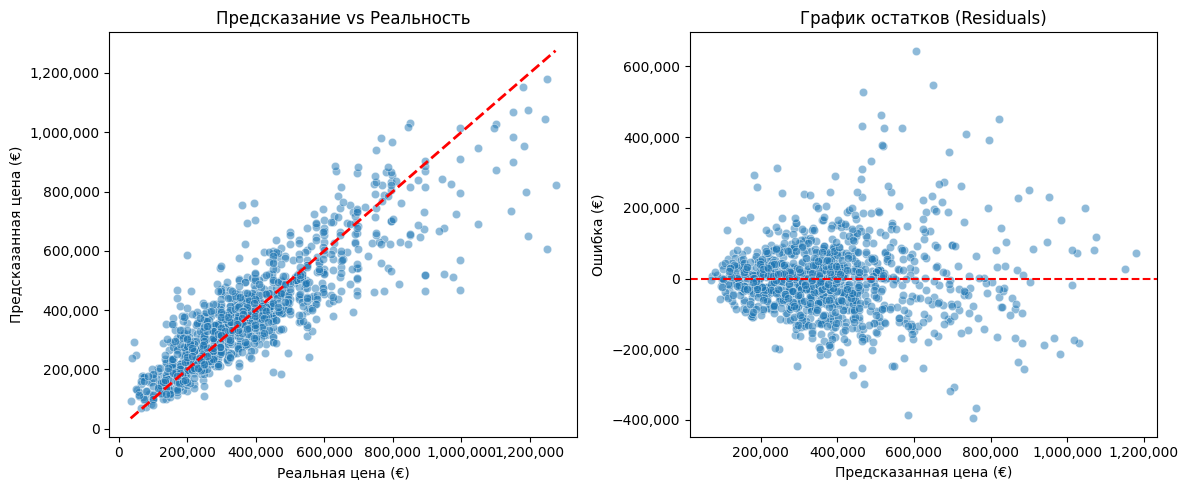

In [144]:
# The beauty of Path B: predict() returns Euros automatically
y_pred_final = best_model_final.predict(X_test_encoded[final_features])

# Now just run your plotting function
plot_model_performance(y_test, y_pred_final)

## Stacking Engine - using not only the final model, but a mix of models from the grid search (e.g. top 3-5) to create a meta-model that learns from their predictions. This can often boost performance by leveraging the strengths of multiple algorithms. ##

In [152]:
def run_production_ready_block_2(X_train_encoded, y_train, X_test_encoded, y_test, best_model_initial, numeric_cols):
    print(f"\n--- Starting Universal Block 2 (Stacking Ensemble & Log-Path) ---")

    # 1. PREPARE BASE ESTIMATORS
    # Extract the winning model object from Block 1's TransformedTargetRegressor
    inner_pipeline = best_model_initial.regressor_
    winner_model_obj = inner_pipeline.steps[-1][1]
    
    # We build a "Dream Team" of diverse models to reduce variance
    estimators = [
        ('winner', clone(winner_model_obj)),
        ('ridge', Ridge(alpha=1.0)),
        ('rf', RandomForestRegressor(n_estimators=100, max_depth=10, random_state=42))
    ]
    
    print(f"Stacking Ensemble members: {[name for name, _ in estimators]}")

    # 2. FEATURE SELECTION (Using RFECV on the Winner model)
    # We drop categorical text columns for mathematical selection
    geo_text_cols = ['zip_code', 'province', 'region']
    X_train_math = X_train_encoded.drop(columns=geo_text_cols, errors='ignore').astype(float)
    constant_cols = [c for c in X_train_math.columns if X_train_math[c].nunique() <= 1]
    X_train_vif_input = X_train_math.drop(columns=constant_cols)

    print(f"Running RFECV for optimal feature subset...")
    selector_model = clone(winner_model_obj)
    rfecv = RFECV(estimator=selector_model, step=1, cv=3, scoring='r2', n_jobs=-1)
    # Target must be logged manually for RFECV since it's outside the wrapper
    rfecv.fit(X_train_vif_input, np.log1p(y_train))

    final_features = X_train_vif_input.columns[rfecv.support_].tolist()
    print(f"Features selected: {len(final_features)}")

    # 3. DEFINE PREPROCESSOR FOR SELECTED FEATURES
    final_numeric_cols = [col for col in numeric_cols if col in final_features]
    final_passthrough_cols = [col for col in final_features if col not in final_numeric_cols]

    preprocessor_final = ColumnTransformer(transformers=[
        ('num_poly', Pipeline([
            ('scaler', StandardScaler()),
            ('poly', PolynomialFeatures(degree=1, include_bias=False))
        ]), final_numeric_cols),
        ('just_scale', StandardScaler(), final_passthrough_cols)
    ])

    # 4. CONSTRUCT STACKING REGRESSOR
    # Final_estimator (the Judge) is a simple Ridge to prevent overfitting
    stack_reg = StackingRegressor(
        estimators=estimators,
        final_estimator=Ridge(alpha=1.0),
        cv=5,
        n_jobs=-1
    )

    # Wrap the whole logic into a Pipeline
    final_inner_pipe = Pipeline([
        ('preprocessor', preprocessor_final),
        ('model', stack_reg)
    ])

    # Final wrapper for automatic log-transformation (Path B)
    best_model_final = TransformedTargetRegressor(
        regressor=final_inner_pipe,
        func=np.log1p,
        inverse_func=np.expm1
    )

    # 5. TRAIN & EVALUATE
    print("Training the Meta-Model Stacking Ensemble...")
    best_model_final.fit(X_train_encoded[final_features], y_train)

    # Calculate CV R2 (The "Exam during study")
    print("Calculating Cross-Validation R2 (this may take 1-2 minutes)...")
    cv_scores = cross_val_score(best_model_final, X_train_encoded[final_features], y_train, cv=3, scoring='r2', n_jobs=-1)
    r2_best_cv_final = cv_scores.mean()

    # Predictions on unseen data
    y_pred_final = best_model_final.predict(X_test_encoded[final_features])

    # 6. METRICS CALCULATION
    # Get feature names from fitted regressor_
    feature_names_final = best_model_final.regressor_.named_steps['preprocessor'].get_feature_names_out()
    
    r2_final = r2_score(y_test, y_pred_final)
    n_final = len(y_test)
    k_final = len(feature_names_final)
    adj_r2_final = 1 - (1 - r2_final) * (n_final - 1) / (n_final - k_final - 1)
    mae_final = mean_absolute_error(y_test, y_pred_final)

    # 7. EXTRACT META-MODEL WEIGHTS
    # The final_estimator_ holds the coefficients for our base models
    meta_model = best_model_final.regressor_.named_steps['model'].final_estimator_
    weights = meta_model.coef_
    
    print(f"\n{'='*40}")
    print(f"FINAL STACKING RESULTS (Path B)")
    print(f"Meta-Model (Judge): {type(meta_model).__name__}")
    print(f"Best CV R2 (Ensemble): {r2_best_cv_final:.4f}")
    print(f"Test R2 (Unseen Data): {r2_final:.4f}")
    print(f"Test Adjusted R2: {adj_r2_final:.4f}")
    print(f"Test MAE: {mae_final:,.0f} €")
    print(f"Final Feature Count: {k_final}")
    print(f"{'-'*40}")
    print(f"META-MODEL WEIGHTS (Importance of each expert):")
    for name, weight in zip([n for n, _ in estimators], weights):
        print(f" - {name}: {weight:.4f}")
    print(f"{'='*40}")
 
    # --- DETAILED SEGMENT ANALYSIS ---
    analysis_df = pd.DataFrame({'True': y_test, 'Pred': y_pred_final})
    analysis_df['Abs_Error'] = np.abs(analysis_df['True'] - analysis_df['Pred'])
    analysis_df['Pct_Error'] = (analysis_df['Abs_Error'] / analysis_df['True']) * 100

    med_ape = analysis_df['Pct_Error'].median()
    mape_total = analysis_df['Pct_Error'].mean()

    mass_market = analysis_df[analysis_df['True'] <= 450000]
    mae_mass = mass_market['Abs_Error'].mean()
    mape_mass = mass_market['Pct_Error'].mean()

    mid_market = analysis_df[(analysis_df['True'] > 450000) & (analysis_df['True'] <= 800000)]
    mae_mid = mid_market['Abs_Error'].mean()
    mape_mid = mid_market['Pct_Error'].mean()


    luxury_market = analysis_df[analysis_df['True'] > 800000]
    mae_luxury = luxury_market['Abs_Error'].mean()
    mape_luxury = luxury_market['Pct_Error'].mean()

    print(f"\n--- Deep Error Analysis ---")
    print(f"Overall Mean Absolute Percentage Error (MAPE): {mape_total:.2f}%")
    print(f"Overall Median Error (Median APE): {med_ape:.2f}%")
    print(f"\nSegment Breakdown:")
    print(f"\n1.Mass Market Segment (Up to 450k €):")
    print(f" - Average Error (MAE): {mae_mass:,.0f} €")
    print(f" - Average Error (%): {mape_mass:.2f}%")

    print(f"\n2.Mid-Market Segment (450k € - 800k €):")
    print(f" - Average Error (MAE): {mae_mid:,.0f} €")
    print(f" - Average Error (%): {mape_mid:.2f}%")
    
    print(f"\n3.Luxury Segment (Above 800k €):")
    print(f" - Average Error (MAE): {mae_luxury:,.0f} €")
    print(f" - Average Error (%): {mape_luxury:.2f}%")
    print(f"{'='*40}")

    return best_model_final, final_features, r2_best_cv_final, r2_final, adj_r2_final, mae_final, k_final

In [153]:
best_model_final_log, feature_names_final_log, r2_best_cv_final_log, r2_base_final_log, adj_r2_base_final_log, MAE_base_final_log, k_base_final_log = run_production_ready_block_2(X_train_encoded, y_train, X_test_encoded, y_test, best_model_initial_log, numeric_cols)
print(best_model_final_log)
print(feature_names_final_log)
print(r2_best_cv_final_log)
print(r2_base_final_log)
print(adj_r2_base_final_log)
print(MAE_base_final_log)
print(k_base_final_log)


--- Starting Universal Block 2 (Stacking Ensemble & Log-Path) ---
Stacking Ensemble members: ['winner', 'ridge', 'rf']
Running RFECV for optimal feature subset...
Features selected: 21
Training the Meta-Model Stacking Ensemble...
Calculating Cross-Validation R2 (this may take 1-2 minutes)...

FINAL STACKING RESULTS (Path B)
Meta-Model (Judge): Ridge
Best CV R2 (Ensemble): 0.7587
Test R2 (Unseen Data): 0.7513
Test Adjusted R2: 0.7467
Test MAE: 74,926 €
Final Feature Count: 21
----------------------------------------
META-MODEL WEIGHTS (Importance of each expert):
 - winner: 0.8385
 - ridge: 0.1347
 - rf: 0.0455

--- Deep Error Analysis ---
Overall Mean Absolute Percentage Error (MAPE): 23.16%
Overall Median Error (Median APE): 15.85%

Segment Breakdown:

1.Mass Market Segment (Up to 450k €):
 - Average Error (MAE): 57,929 €
 - Average Error (%): 25.27%

2.Mid-Market Segment (450k € - 800k €):
 - Average Error (MAE): 98,437 €
 - Average Error (%): 16.72%

3.Luxury Segment (Above 800k €)

# APARTMENTS #

In [ ]:
y = df_apartments['price']
X = df_apartments.drop(columns=['price'])

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [ ]:
print("X_train:", X_train.shape)
print("X_test:", X_test.shape)
print("y_train:", y_train.shape)
print("y_test:", y_test.shape)

In [ ]:
df_apartments.groupby('type_of_property')['subtype_of_property'].value_counts()

In [ ]:
# columns to fill with medians
median_cols = ['living_area', 'terrace_area', 'garden_area']

# columns to fll with modes
mode_cols = ['number_of_facades', 'number_of_rooms']

# group by Region
group_cols = ['region']

In [ ]:
train_medians, train_modes = fit_group_imputer(
    X_train,
    median_cols,
    mode_cols,
    group_cols
)

In [ ]:
print(train_medians)

In [ ]:
print(train_modes)

In [ ]:
# Appling to X_train and X_test
X_train = transform_group_imputer(
    X_train,
    train_medians,
    train_modes,
    median_cols,
    mode_cols,
    group_cols
)
# USING SAME MEDIANS AND MODES AS FOR X_TRAIN
X_test = transform_group_imputer(
    X_test,
    train_medians,
    train_modes,
    median_cols,
    mode_cols,
    group_cols
)

In [ ]:
# # int64 + bool
# num_cols = X_train.select_dtypes(include=['Int64','bool']).columns

# # bool -> int
# X_numeric = X_train[num_cols].copy()
# for col in X_numeric.select_dtypes(include='bool'):
#     X_numeric[col] = X_numeric[col].astype('Int64')

# # correlation matrix for variables (without y)
# corr_matrix = X_numeric.corr()

# print(corr_matrix)

In [ ]:
# checking VIF / multicollinearity

for col in X_numeric.columns:
    if X_numeric[col].dtype == 'bool':
        X_numeric[col] = X_numeric[col].astype(float)
    elif X_numeric[col].dtype.name == 'Int64':
        X_numeric[col] = X_numeric[col].astype(float)  # medium_price_per_sqm became FLOAT

vif_data = pd.DataFrame()
X_numeric_const = add_constant(X_numeric)
vif_data["feature"] = X_numeric_const.columns
vif_data["VIF"] = [variance_inflation_factor(X_numeric_const.values, i) 
                   for i in range(X_numeric_const.shape[1])]
vif_data = vif_data.sort_values(by="VIF", ascending=False)
print(vif_data)

In [ ]:
# checking correlation with price
corr_with_target = X_train[num_cols].corrwith(y_train)
print(corr_with_target.sort_values(ascending=False))

In [ ]:
#check_linear_relationships(X_train, y_train)

In [ ]:
cols_to_drop = ['city', 'province', 'type_of_sale', 'type_of_property']
X_train = X_train.drop(columns=cols_to_drop)
X_test = X_test.drop(columns=cols_to_drop)

# One-hot for categorical data (only some for now)
categorical_cols = ['region', 'subtype_of_property']
X_train_encoded = pd.get_dummies(X_train, columns=categorical_cols, drop_first=True)
X_test_encoded  = pd.get_dummies(X_test, columns=categorical_cols, drop_first=True)

X_test_encoded = X_test_encoded.reindex(columns=X_train_encoded.columns, fill_value=0)

# Bool -> Int64
bool_cols = X_train_encoded.select_dtypes(include='bool').columns
X_train_encoded[bool_cols] = X_train_encoded[bool_cols].astype('Int64')
X_test_encoded[bool_cols]  = X_test_encoded[bool_cols].astype('Int64')

In [ ]:
#X_train_encoded.info()

In [ ]:
#X_test_encoded.info()

In [ ]:
X_train_encoded.columns

In [ ]:
# =================================================================
# BLOCK 1: INITIAL MODEL SELECTION (BASELINE)
# =================================================================

# 1. Define your initial numeric features
numeric_cols = ['number_of_rooms', 'living_area', 'terrace_area', 'garden_area', 'state_of_the_building']

# Define passthrough columns (categorical/binary)
passthrough_cols = [col for col in X_train_encoded.columns if col not in numeric_cols]

# Preprocessing Pipeline
preprocessor = ColumnTransformer(
    transformers=[
        ('num_poly', Pipeline([
            ('scaler', StandardScaler()),
            ('poly', PolynomialFeatures(include_bias=False))
        ]), numeric_cols),
        ('just_scale', StandardScaler(), passthrough_cols)
    ]
)

# Main Pipeline
pipe = Pipeline([
    ('preprocessor', preprocessor),
    ('model', LinearRegression()) 
])

# Param grid for various models
param_grid = [
    {'preprocessor__num_poly__poly__degree': [1, 2], 'model': [LinearRegression()]},
    {
        'preprocessor__num_poly__poly__degree': [1, 2],
        'model': [Lasso(max_iter=20000), Ridge()],
        'model__alpha': [100.0, 1000.0, 5000.0]
    },
    {
        'preprocessor__num_poly__poly__degree': [1],
        'model': [RandomForestRegressor(random_state=42)],
        'model__n_estimators': [100, 200],
        'model__max_depth': [10, 20, None],
        'model__min_samples_leaf': [1, 2, 4]
    },
    {
        'preprocessor__num_poly__poly__degree': [1],
        'model': [XGBRegressor(random_state=42, n_jobs=-1, verbosity=0)],
        'model__n_estimators': [500, 1000],
        'model__learning_rate': [0.01, 0.05, 0.1],
        'model__max_depth': [3, 5, 7],
        'model__subsample': [0.8, 1.0]
    }
]

# Ensure test set columns match training set
X_test_encoded = X_test_encoded.reindex(columns=X_train_encoded.columns, fill_value=0)

# Run GridSearchCV
grid = GridSearchCV(pipe, param_grid, cv=5, scoring='r2', n_jobs=-1, verbose=1)
grid.fit(X_train_encoded, y_train)

# --- BASELINE METRICS CALCULATION ---
best_model_initial = grid.best_estimator_
y_pred_base = best_model_initial.predict(X_test_encoded)

# Get feature names to count them correctly (including polynomials)
feature_names_base = best_model_initial.named_steps['preprocessor'].get_feature_names_out()
r2_base = r2_score(y_test, y_pred_base)
n_base = len(y_test)
k_base = len(feature_names_base)
adj_r2_base = 1 - (1 - r2_base) * (n_base - 1) / (n_base - k_base - 1)

print(f"\n{'='*40}")
print(f"BASELINE RESULTS (All Features)")
print(f"Winner Model: {grid.best_params_['model']}")
print(f"Best CV R2: {grid.best_score_:.4f}")
print(f"Test R2: {r2_base:.4f}")
print(f"Test Adjusted R2: {adj_r2_base:.4f}")
print(f"Test MAE: {mean_absolute_error(y_test, y_pred_base):,.0f} €")
print(f"Final Feature Count: {k_base}")
print(f"{'='*40}")

In [ ]:
# import matplotlib.pyplot as plt

# residuals = y_test - y_pred

# plt.figure(figsize=(10, 6))
# plt.scatter(y_pred, residuals, alpha=0.5)
# plt.axhline(y=0, color='r', linestyle='--')
# plt.xlabel('y_pred')
# plt.ylabel('Error (Real - Predicted)')
# plt.title('XGBoost Error Analysis')
# plt.show()

In [ ]:
# vif_data = pd.DataFrame()
# X_train_encoded_const = add_constant(X_train_encoded)
# vif_data["feature"] = X_train_encoded_const.columns

# # need FLOAT to calculate metrics
# vif_data["VIF"] = [
#     variance_inflation_factor(X_train_encoded_const.astype(float).values, i) 
#     for i in range(X_train_encoded_const.shape[1])
# ]

# vif_data = vif_data.sort_values(by="VIF", ascending=False)
# print(vif_data)

In [ ]:
# =================================================================
# BLOCK 2: VIF, RFECV, AND FINAL MODEL RUN
# =================================================================

# 1. VIF: Remove Multicollinearity
X_train_float = X_train_encoded.astype(float)
# Automatically drop columns with zero variance (all zeros/ones)
constant_cols = [c for c in X_train_float.columns if X_train_float[c].nunique() <= 1]
X_train_vif_input = X_train_float.drop(columns=constant_cols)

X_const = add_constant(X_train_vif_input)
vif_data = pd.DataFrame()
vif_data["feature"] = X_const.columns
vif_data["VIF"] = [variance_inflation_factor(X_const.values, i) for i in range(X_const.shape[1])]

selected_vif_features = vif_data[vif_data["VIF"] < 10]["feature"].tolist()
if 'const' in selected_vif_features: selected_vif_features.remove('const')

# 2. RFECV: Feature Selection with XGBoost
xgb_selector = XGBRegressor(n_estimators=100, learning_rate=0.05, max_depth=5, random_state=42, n_jobs=-1, verbosity=0)
rfecv = RFECV(estimator=xgb_selector, step=1, cv=5, scoring='r2', n_jobs=-1)

X_train_vif_filtered = X_train_vif_input[selected_vif_features]
rfecv.fit(X_train_vif_filtered, y_train)

final_features = X_train_vif_filtered.columns[rfecv.support_].tolist()

# 3. Final Model Execution (Using winner architecture from Block 1)
# Important: Update the lists based on final_features
final_numeric_cols = [col for col in numeric_cols if col in final_features]
final_passthrough_cols = [col for col in final_features if col not in final_numeric_cols]

preprocessor_final = ColumnTransformer(
    transformers=[
        ('num_poly', Pipeline([
            ('scaler', StandardScaler()),
            ('poly', PolynomialFeatures(include_bias=False))
        ]), final_numeric_cols),
        ('just_scale', StandardScaler(), final_passthrough_cols)
    ]
)

# Re-run GridSearch specifically on the optimized feature set
final_pipe = Pipeline([
    ('preprocessor', preprocessor_final),
    ('model', LinearRegression()) # Placeholder, param_grid will swap this
])

X_train_final = X_train_encoded[final_features]
X_test_final = X_test_encoded[final_features]

grid_final = GridSearchCV(final_pipe, param_grid, cv=5, scoring='r2', n_jobs=-1, verbose=1)
grid_final.fit(X_train_final, y_train)

# 4. FINAL RESULTS & COMPARISON
best_model_final = grid_final.best_estimator_
y_pred_final = best_model_final.predict(X_test_final)

feature_names_final = best_model_final.named_steps['preprocessor'].get_feature_names_out()
r2_final = r2_score(y_test, y_pred_final)
n_final = len(y_test)
k_final = len(feature_names_final)
adj_r2_final = 1 - (1 - r2_final) * (n_final - 1) / (n_final - k_final - 1)

print(f"\n{'='*40}")
print(f"OPTIMIZED RESULTS (Reduced Features)")
print(f"Winner Model: {grid_final.best_params_['model']}")
print(f"Best CV R2: {grid_final.best_score_:.4f}")
print(f"Test R2: {r2_final:.4f}")
print(f"Test Adjusted R2: {adj_r2_final:.4f}")
print(f"Test MAE: {mean_absolute_error(y_test, y_pred_final):,.0f} €")
print(f"Final Feature Count: {k_final}")
print(f"{'='*40}")

# List all features used in the final model
print("\n--- FINAL FEATURE LIST ---")
for i, name in enumerate(feature_names_final, 1):
    print(f"{i}. {name}")